# Imports

In [1]:
import sys
import os
import uproot

# Añade el directorio padre al sys.path
sys.path.append(os.path.abspath("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk"))

import hipy.hipy.pltext  as pltext
import matplotlib.pyplot as plt
import awkward           as ak
import numpy             as np
import pandas            as pd

from nHits_trigger.src.read_data          import nHits, read_mpmt_offsets
from WCTE_BRB_Data_Analysis.wcte.brbtools import sort_run_files, get_part_files
from matplotlib.backends.backend_pdf      import PdfPages

from tqdm import tqdm

plt.style.use('default');
pltext.style()

# Read Data And Correct TOF

In [2]:
bkg_run = 1766

bkg_run_files  = sort_run_files(f"/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/raw_data/production_v0/{bkg_run}/WCTE_offline_R{bkg_run}S*P*.root")
bkg_part_files = get_part_files(bkg_run_files)

# Run Variables
bkg_run_corrected_times           = []
bkg_run_hit_charges               = []
bkg_run_hit_card_ids              = []
bkg_run_hit_channel_ids           = []
bkg_run_hit_slot_ids              = []
bkg_run_hit_position_ids          = []
bkg_run_hit_pmt_has_time_constant = []

ev_offset = 0
for part in bkg_part_files[:2]:
    print(f"Processing part WCTE_offline_R{bkg_run}S0P{part}")
    bkg_tree = uproot.open(bkg_run_files[part] + ":WCTEReadoutWindows")
    
    # Read the variables
    bkg_file_hit_card_ids              = ak.values_astype(bkg_tree["hit_mpmt_card_ids"]        .array(), np.int16)
    bkg_file_hit_channel_ids           = ak.values_astype(bkg_tree["hit_pmt_channel_ids"]      .array(), np.int8)
    bkg_file_hit_times                 = ak.values_astype(bkg_tree["hit_pmt_times"]            .array(), np.float64)
    bkg_file_hit_times_calib           = ak.values_astype(bkg_tree["hit_pmt_calibrated_times"] .array(), np.float64)
    bkg_file_hit_charges               = ak.values_astype(bkg_tree["hit_pmt_charges"]          .array(), np.float64)
    bkg_file_hit_slot_ids              = ak.values_astype(bkg_tree["hit_mpmt_slot_ids"]        .array(), np.int16)
    bkg_file_hit_position_ids          = ak.values_astype(bkg_tree["hit_pmt_position_ids"]     .array(), np.int16)
    bkg_file_hit_pmt_has_time_constant = ak.values_astype(bkg_tree["hit_pmt_has_time_constant"].array(), np.bool)

    mpmt_map = read_mpmt_offsets("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/mpmt_tof_map/mpmt_tof_pos1767.json")

    max_slot = 106
    max_pos  = 19

    # Build lookup
    lookup = np.zeros((max_slot, max_pos))
    for (card, chan), shift in mpmt_map.items():
        lookup[card, chan] = shift

    # Hit Times Correction
    bkg_flat_slot_ids     = ak.ravel(bkg_file_hit_slot_ids)
    bkg_flat_pos_ids      = ak.ravel(bkg_file_hit_position_ids)
    bkg_flat_corrections  = lookup[bkg_flat_slot_ids, bkg_flat_pos_ids]
    bkg_corrections       = ak.unflatten(bkg_flat_corrections, ak.num(bkg_file_hit_card_ids))

    bkg_term1           = bkg_file_hit_times_calib
    bkg_corrected_times = bkg_term1 #- bkg_corrections 

    # Filter Out Main Things
    mask = (bkg_file_hit_charges < 1e4) & (bkg_file_hit_card_ids < 120) & (bkg_file_hit_pmt_has_time_constant != 0)
    bkg_corrected_times                = bkg_corrected_times                [mask]
    bkg_file_hit_charges               = bkg_file_hit_charges               [mask]
    bkg_file_hit_card_ids              = bkg_file_hit_card_ids              [mask]
    bkg_file_hit_channel_ids           = bkg_file_hit_channel_ids           [mask]
    bkg_file_hit_slot_ids              = bkg_file_hit_slot_ids              [mask]
    bkg_file_hit_position_ids          = bkg_file_hit_position_ids          [mask]
    bkg_file_hit_pmt_has_time_constant = bkg_file_hit_pmt_has_time_constant [mask]

    # SUPER IMPORTANT! We want the hit time time-ordered, and we want to order the other variables the same way so later we can filter out by index in the array
    order = ak.argsort(bkg_corrected_times)
    
    bkg_run_corrected_times          .append(bkg_corrected_times               [order])
    bkg_run_hit_charges              .append(bkg_file_hit_charges              [order])
    bkg_run_hit_card_ids             .append(bkg_file_hit_card_ids             [order])    
    bkg_run_hit_channel_ids          .append(bkg_file_hit_channel_ids          [order]) 
    bkg_run_hit_slot_ids             .append(bkg_file_hit_slot_ids             [order])    
    bkg_run_hit_position_ids         .append(bkg_file_hit_position_ids         [order])
    bkg_run_hit_pmt_has_time_constant.append(bkg_file_hit_pmt_has_time_constant[order])

bkg_run_corrected_times           = ak.concatenate(bkg_run_corrected_times          )
bkg_run_hit_charges               = ak.concatenate(bkg_run_hit_charges              )
bkg_run_hit_card_ids              = ak.concatenate(bkg_run_hit_card_ids             )
bkg_run_hit_channel_ids           = ak.concatenate(bkg_run_hit_channel_ids          )
bkg_run_hit_slot_ids              = ak.concatenate(bkg_run_hit_slot_ids             )
bkg_run_hit_position_ids          = ak.concatenate(bkg_run_hit_position_ids         )
bkg_run_hit_pmt_has_time_constant = ak.concatenate(bkg_run_hit_pmt_has_time_constant)

Processing part WCTE_offline_R1766S0P0
Processing part WCTE_offline_R1766S0P1


In [3]:
nicf_run = 1767

nicf_run_files  = sort_run_files(f"/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/raw_data/production_v0/{nicf_run}/WCTE_offline_R{nicf_run}S*P*.root")
nicf_part_files = get_part_files(nicf_run_files)

# Run Variables
nicf_run_tof_corrected_times           = []
nicf_run_tof_hit_charges               = []
nicf_run_tof_hit_card_ids              = []
nicf_run_tof_hit_channel_ids           = []
nicf_run_tof_hit_slot_ids              = []
nicf_run_tof_hit_position_ids          = []
nicf_run_tof_hit_pmt_has_time_constant = []

ev_offset = 0
for part in nicf_part_files[:2]:
    print(f"Processing part WCTE_offline_R{nicf_run}S0P{part}")
    nicf_tree = uproot.open(nicf_run_files[part] + ":WCTEReadoutWindows")
    
    # Read the variables
    nicf_file_hit_card_ids              = ak.values_astype(nicf_tree["hit_mpmt_card_ids"]        .array(), np.int16)
    nicf_file_hit_channel_ids           = ak.values_astype(nicf_tree["hit_pmt_channel_ids"]      .array(), np.int8)
    nicf_file_hit_times                 = ak.values_astype(nicf_tree["hit_pmt_times"]            .array(), np.float64)
    nicf_file_hit_times_calib           = ak.values_astype(nicf_tree["hit_pmt_calibrated_times"] .array(), np.float64)
    nicf_file_hit_charges               = ak.values_astype(nicf_tree["hit_pmt_charges"]          .array(), np.float64)
    nicf_file_hit_slot_ids              = ak.values_astype(nicf_tree["hit_mpmt_slot_ids"]        .array(), np.int16)
    nicf_file_hit_position_ids          = ak.values_astype(nicf_tree["hit_pmt_position_ids"]     .array(), np.int16)
    nicf_file_hit_pmt_has_time_constant = ak.values_astype(nicf_tree["hit_pmt_has_time_constant"].array(), np.bool)

    mpmt_map = read_mpmt_offsets("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/mpmt_tof_map/mpmt_tof_pos1767.json")

    max_slot = 106
    max_pos  = 19

    # Build lookup
    lookup = np.zeros((max_slot, max_pos))
    for (card, chan), shift in mpmt_map.items():
        lookup[card, chan] = shift

    # Hit Times Correction
    nicf_flat_slot_ids     = ak.ravel(nicf_file_hit_slot_ids)
    nicf_flat_pos_ids      = ak.ravel(nicf_file_hit_position_ids)
    nicf_flat_corrections  = lookup[nicf_flat_slot_ids, nicf_flat_pos_ids]
    nicf_corrections       = ak.unflatten(nicf_flat_corrections, ak.num(nicf_file_hit_card_ids))

    nicf_term1           = nicf_file_hit_times_calib
    nicf_corrected_times = nicf_term1 - nicf_corrections 

    # Filter Out Main Things
    mask = (nicf_file_hit_charges < 1e4) & (nicf_file_hit_card_ids < 120) & (nicf_file_hit_pmt_has_time_constant != 0)
    nicf_corrected_times                = nicf_corrected_times                [mask]
    nicf_file_hit_charges               = nicf_file_hit_charges               [mask]
    nicf_file_hit_card_ids              = nicf_file_hit_card_ids              [mask]
    nicf_file_hit_channel_ids           = nicf_file_hit_channel_ids           [mask]
    nicf_file_hit_slot_ids              = nicf_file_hit_slot_ids              [mask]
    nicf_file_hit_position_ids          = nicf_file_hit_position_ids          [mask]
    nicf_file_hit_pmt_has_time_constant = nicf_file_hit_pmt_has_time_constant [mask]

    # SUPER IMPORTANT! We want the hit time time-ordered, and we want to order the other variables the same way so later we can filter out by index in the array
    order = ak.argsort(nicf_corrected_times)
    
    nicf_run_tof_corrected_times          .append(nicf_corrected_times               [order])
    nicf_run_tof_hit_charges              .append(nicf_file_hit_charges              [order])
    nicf_run_tof_hit_card_ids             .append(nicf_file_hit_card_ids             [order])    
    nicf_run_tof_hit_channel_ids          .append(nicf_file_hit_channel_ids          [order]) 
    nicf_run_tof_hit_slot_ids             .append(nicf_file_hit_slot_ids             [order])    
    nicf_run_tof_hit_position_ids         .append(nicf_file_hit_position_ids         [order])
    nicf_run_tof_hit_pmt_has_time_constant.append(nicf_file_hit_pmt_has_time_constant[order])

nicf_run_tof_corrected_times           = ak.concatenate(nicf_run_tof_corrected_times          )
nicf_run_tof_hit_charges               = ak.concatenate(nicf_run_tof_hit_charges              )
nicf_run_tof_hit_card_ids              = ak.concatenate(nicf_run_tof_hit_card_ids             )
nicf_run_tof_hit_channel_ids           = ak.concatenate(nicf_run_tof_hit_channel_ids          )
nicf_run_tof_hit_slot_ids              = ak.concatenate(nicf_run_tof_hit_slot_ids             )
nicf_run_tof_hit_position_ids          = ak.concatenate(nicf_run_tof_hit_position_ids         )
nicf_run_tof_hit_pmt_has_time_constant = ak.concatenate(nicf_run_tof_hit_pmt_has_time_constant)

Processing part WCTE_offline_R1767S0P0


Processing part WCTE_offline_R1767S0P1


# Spills

In [4]:
len(bkg_run_corrected_times) == len(nicf_run_tof_corrected_times)

True

In [5]:
nicf_triggered_spill_hits_index_tof, nicf_triggered_spill_hit_times_tof = nHits(mode="multiple_events", hit_times=nicf_run_tof_corrected_times, w=5000, thresh_min=300, thresh_max=100000, pre_window=0, post_window=4000, jump=9000)
bkg_triggered_spill_hits_index, bkg_triggered_spill_hit_times           = nHits(mode="multiple_events", hit_times=bkg_run_corrected_times,      w=5000, thresh_min=300, thresh_max=100000, pre_window=0, post_window=4000, jump=9000)

100%|██████████| 29108/29108 [00:12<00:00, 2372.05it/s]


### Remove Spills from data

In [6]:
def remove_spill(trigger_indices, run_times):
    corrected_run_times = []

    for i in tqdm(range(len(run_times))):
        if i in trigger_indices:
            #Event with spill → remove selected indices
            if len(trigger_indices[i]) > 0:
                data = run_times[i]
                trigger_indices_event = np.concatenate(trigger_indices[i])
                all_indices           = np.arange(len(data))
                valid_indices         = np.setdiff1d(all_indices, trigger_indices_event)
                corrected_run_times.append(data[valid_indices])
            
            else:
                continue
        else:
            # Event without spill → leave as it is
            corrected_run_times.append(run_times[i])

    return ak.Array(corrected_run_times)

In [7]:
# Hit Time
nicf_noSpill_times_tof = remove_spill(nicf_triggered_spill_hits_index_tof, nicf_run_tof_corrected_times)
bkg_noSpill_times      = remove_spill(bkg_triggered_spill_hits_index, bkg_run_corrected_times)

100%|██████████| 29108/29108 [00:06<00:00, 4288.62it/s]


### Spill Analysis

In [8]:
#¿Cuántos spill estoy quitando por readout-window?

nOfSpillsPerEvent_sig = []
for k,v in nicf_triggered_spill_hit_times_tof.items():
    nOfSpillsPerEvent_sig.append(len(v))

nOfSpillsPerEvent_bkg = []
for k,v in bkg_triggered_spill_hit_times.items():
    nOfSpillsPerEvent_bkg.append(len(v))

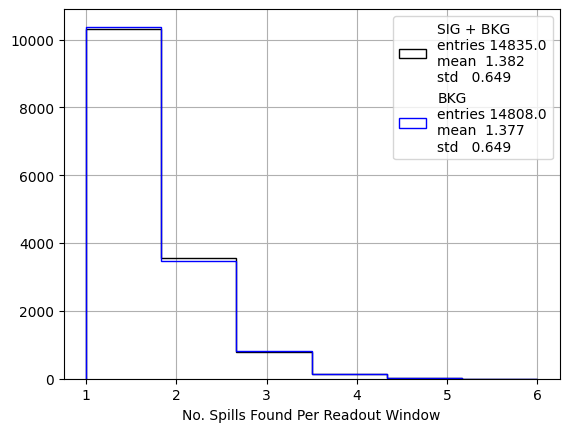

In [9]:
pltext.hist(nOfSpillsPerEvent_sig, np.max(nOfSpillsPerEvent_sig), xylabels="No. Spills Found Per Readout Window", label="SIG + BKG");
pltext.hist(nOfSpillsPerEvent_bkg, np.max(nOfSpillsPerEvent_bkg), xylabels="No. Spills Found Per Readout Window", label="BKG");

In [10]:
# Distribución del número de hits en el spill (en 5000 ns y en los 4000 ns posteriores)

spill_size_sig = []

for k,v in tqdm(nicf_triggered_spill_hit_times_tof.items(), total=len(nicf_triggered_spill_hit_times_tof.items()), leave=False):
    for i in nicf_triggered_spill_hit_times_tof.get(k):
        spill_size_sig.append(len(i))

spill_size_bkg = []

for k,v in tqdm(bkg_triggered_spill_hit_times.items(), total=len(bkg_triggered_spill_hit_times.items()), leave=False):
    for i in bkg_triggered_spill_hit_times.get(k):
        spill_size_bkg.append(len(i))

  0%|          | 0/14808 [00:00<?, ?it/s]

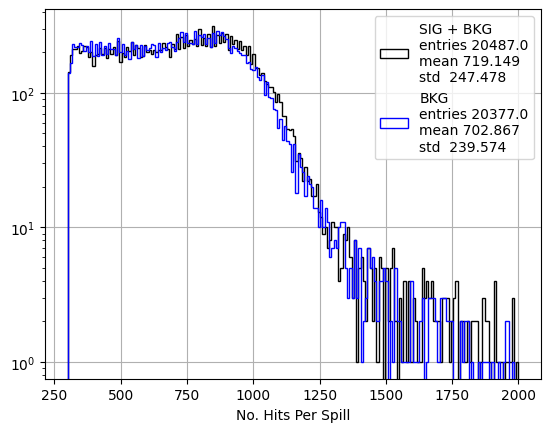

In [11]:
pltext.hist(spill_size_sig, 200, range=(300, 2000), ylog=True, xylabels="No. Hits Per Spill", label="SIG + BKG");
pltext.hist(spill_size_bkg, 200, range=(300, 2000), ylog=True, xylabels="No. Hits Per Spill", label="BKG");

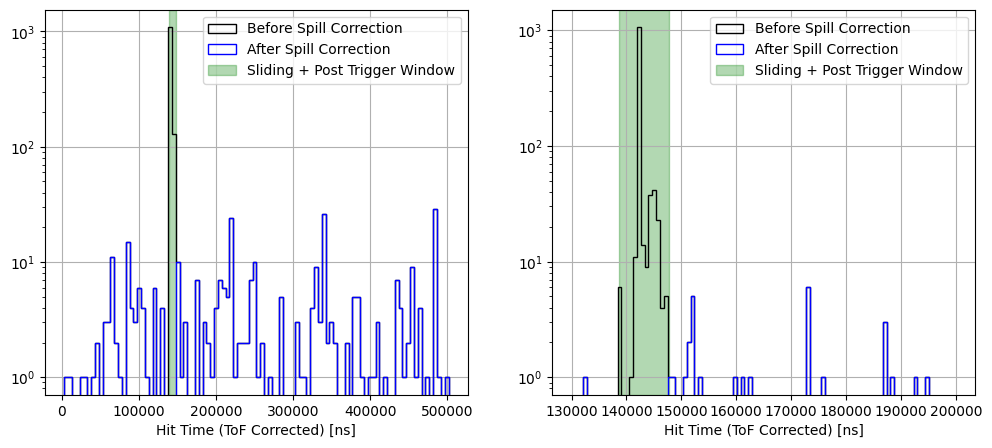

In [12]:
ev = 0

subplot = pltext.canvas(2)

subplot(1)
pltext.hist(nicf_run_tof_corrected_times[ev], 100, ylog=True, xylabels="Hit Time (ToF Corrected) [ns]", stats=False, label="Before Spill Correction");
pltext.hist(nicf_noSpill_times_tof[ev],       100, ylog=True, xylabels="Hit Time (ToF Corrected) [ns]", stats=False, label="After Spill Correction");
plt.axvspan(nicf_triggered_spill_hit_times_tof[ev][0][0], nicf_triggered_spill_hit_times_tof[ev][0][0]+9e3, color="green", alpha=0.3, label="Sliding + Post Trigger Window");
plt.legend();

subplot(2)
pltext.hist(nicf_run_tof_corrected_times[ev], 100, range=(1.3e5, 2e5), ylog=True, xylabels="Hit Time (ToF Corrected) [ns]", stats=False, label="Before Spill Correction");
pltext.hist(nicf_noSpill_times_tof[ev],       100, range=(1.3e5, 2e5), ylog=True, xylabels="Hit Time (ToF Corrected) [ns]", stats=False, label="After Spill Correction");
plt.axvspan(nicf_triggered_spill_hit_times_tof[ev][0][0], nicf_triggered_spill_hit_times_tof[ev][0][0]+9e3, color="green", alpha=0.3, label="Sliding + Post Trigger Window");
plt.legend();

# Candidates Analysis

In [63]:
def nHits(mode,
          hit_times,
          w,
          thresh_min,
          thresh_max,
          pre_window,
          post_window,
          jump,
          event=0,
          progress_bar=True):

    def process_event(ht,
                      w,
                      thresh_min,
                      thresh_max,
                      pre_window,
                      post_window,
                      jump):

        if len(ht) == 0:
            return [], [], [], []

        # Orden temporal
        ht = np.sort(ht)

        # ------------------------
        # Sliding window trigger
        # ------------------------

        ends = ht + w
        right = np.searchsorted(ht, ends, side="left")
        left = np.arange(len(ht))
        counts = right - left

        trigger_indices = np.where(counts >= thresh_min)[0]

        triggered_hits_index = []
        triggered_hits_time = []

        trigger_seeds = []      # t_seed (paper SLE crossing)
        roi_start_times = []   # primer hit físico del cluster

        last_cluster_end = -np.inf

        # ------------------------
        # Loop triggers
        # ------------------------

        for idx in trigger_indices:

            t_seed = ht[idx]

            # Deadtime basado en CLUSTER REAL
            if t_seed < last_cluster_end + jump:
                continue

            # ------------------------
            # ROI física
            # ------------------------

            t_min = t_seed - pre_window
            t_max = t_seed + w + post_window

            roi_mask = (ht >= t_min) & (ht <= t_max)
            indices_roi = np.where(roi_mask)[0]

            if len(indices_roi) < thresh_min:
                continue
            
            if thresh_max is not None and len(indices_roi) > thresh_max:
                continue

            hit_times_roi = ht[indices_roi]

            # ------------------------
            # Guardado
            # ------------------------

            triggered_hits_index.append(indices_roi)
            triggered_hits_time.append(hit_times_roi)

            trigger_seeds.append(t_seed)
            roi_start_times.append(hit_times_roi[0])

            # Deadtime real: fin del cluster físico
            last_cluster_end = hit_times_roi[-1]

        return triggered_hits_index, triggered_hits_time, trigger_seeds, roi_start_times

    # ==================================================
    # SINGLE EVENT
    # ==================================================

    if mode == "single_event":

        ht = ak.to_numpy(hit_times[event])

        idxs, times, seeds, roi_starts = process_event(
            ht,
            w,
            thresh_min,
            thresh_max,
            pre_window,
            post_window,
            jump
        )

        return ({event: idxs},
                {event: times},
                {event: seeds},
                {event: roi_starts})

    # ==================================================
    # MULTIPLE EVENTS
    # ==================================================

    elif mode == "multiple_events":

        nevents = len(hit_times)

        triggered_hits_index = {}
        triggered_hits_time = {}
        trigger_seeds_dict = {}
        roi_start_times_dict = {}

        for event in tqdm(range(nevents),
                          total=nevents,
                          leave=progress_bar):

            ht = ak.to_numpy(hit_times[event])

            if len(ht) == 0:
                triggered_hits_index[event] = []
                triggered_hits_time[event] = []
                trigger_seeds_dict[event] = []
                roi_start_times_dict[event] = []
                continue

            idxs, times, seeds, roi_starts = process_event(
                ht,
                w,
                thresh_min,
                thresh_max,
                pre_window,
                post_window,
                jump
            )

            triggered_hits_index[event] = idxs
            triggered_hits_time[event] = times
            trigger_seeds_dict[event] = seeds
            roi_start_times_dict[event] = roi_starts

        return (triggered_hits_index,
                triggered_hits_time,
                trigger_seeds_dict,
                roi_start_times_dict)

    else:
        print("enter a valid mode name")
        return {}, {}, {}, {}


In [64]:
thresh_inf          = 5   # hits
thresh_sup          = 60   # hits
sliding_window      = 20   # ns
pre_trigger_window  = 200
post_trigger_window = 200
dead_time           = pre_trigger_window + post_trigger_window    # ns

# nHits
nicf_triggered_signal_hits_index_tof, nicf_triggered_signal_hit_times_tof, nicf_d_seed_tof, nicf_d_roi_tof = nHits(mode="multiple_events", hit_times=nicf_noSpill_times_tof, w=sliding_window, thresh_min=thresh_inf, thresh_max=thresh_sup, pre_window=pre_trigger_window, post_window=post_trigger_window, jump=dead_time)
bkg_triggered_signal_hits_index_tof, bkg_triggered_signal_hit_times_tof, bkg_d_seed_tof, bkg_d_roi_tof     = nHits(mode="multiple_events", hit_times=bkg_noSpill_times,      w=sliding_window, thresh_min=thresh_inf, thresh_max=thresh_sup, pre_window=pre_trigger_window, post_window=post_trigger_window, jump=dead_time)

# tRMS
nicf_rms_50ns_tof  = []
nicf_50ns_size_tof = []
for k,v in tqdm(nicf_triggered_signal_hit_times_tof.items(), total=len(nicf_triggered_signal_hit_times_tof.items()), leave=False):
        for i in nicf_triggered_signal_hit_times_tof.get(k):
            nicf_rms_50ns_tof.append(np.std(i, ddof=0))
            nicf_50ns_size_tof.append(len(i))

bkg_rms_50ns  = []
bkg_50ns_size = []
for k,v in tqdm(bkg_triggered_signal_hit_times_tof.items(), total=len(bkg_triggered_signal_hit_times_tof.items()), leave=False):
        for i in bkg_triggered_signal_hit_times_tof.get(k):
            bkg_rms_50ns.append(np.std(i, ddof=0))
            bkg_50ns_size.append(len(i))

100%|██████████| 29108/29108 [00:12<00:00, 2330.39it/s]


In [65]:
# Eliminamos ese candidato si en la ventana extendida [200, 20 + 200] hay alguna otra acumulación de hits > 10 en 20 ns 
# (que podemos llamar flash). Esto es en la ventana extendida solo está ese candidado con >10 hits 

doubleCandidates_sig = {}

for k,v in tqdm(nicf_triggered_signal_hit_times_tof.items(), total=len(nicf_triggered_signal_hit_times_tof.items())):
    event = k
    sett  = nicf_triggered_signal_hit_times_tof[event] 
    seed  = nicf_d_seed_tof[event]
    roi   = nicf_d_roi_tof[event]
    for c in range(len(v)):
        
        candidate_to_investigate = [sett[c] - seed[c]]
        thresh_inf               = 5     # hits
        thresh_sup               = np.inf # hits
        sliding_window           = 20     # ns
        pre_trigger_window       = 0      # ns  
        post_trigger_window      = 0      # ns
        dead_time                = sliding_window + post_trigger_window

        test_triggered_signal_hits_index_tof, test_triggered_signal_hit_times_tof, test_d_seed_tof, test_d_roi_tof = nHits(mode="single_event", hit_times=candidate_to_investigate, w=sliding_window, thresh_min=thresh_inf, thresh_max=thresh_sup, pre_window=pre_trigger_window, post_window=post_trigger_window, jump=dead_time, event=0)

        if len(test_triggered_signal_hit_times_tof[0]) > 1:
            # print(k, c, ":", len(test_triggered_signal_hit_times_tof[0]))
            doubleCandidates_sig[k] = c

doubleCandidates_bkg = {}

for k,v in tqdm(bkg_triggered_signal_hit_times_tof.items(), total=len(bkg_triggered_signal_hit_times_tof.items())):
    event = k
    sett  = bkg_triggered_signal_hit_times_tof[event] 
    seed  = bkg_d_seed_tof[event]
    roi   = bkg_d_roi_tof[event]
    for c in range(len(v)):
        
        candidate_to_investigate = [sett[c] - seed[c]]
        thresh_inf               = 5     # hits
        thresh_sup               = np.inf # hits
        sliding_window           = 20     # ns
        pre_trigger_window       = 0      # ns  
        post_trigger_window      = 0      # ns
        dead_time                = sliding_window + post_trigger_window

        test_triggered_signal_hits_index_tof, test_triggered_signal_hit_times_tof, test_d_seed_tof, test_d_roi_tof = nHits(mode="single_event", hit_times=candidate_to_investigate, w=sliding_window, thresh_min=thresh_inf, thresh_max=thresh_sup, pre_window=pre_trigger_window, post_window=post_trigger_window, jump=dead_time, event=0)

        if len(test_triggered_signal_hit_times_tof[0]) > 1:
            # print(k, c, ":", len(test_triggered_signal_hit_times_tof[0]))
            doubleCandidates_bkg[k] = c

100%|██████████| 29108/29108 [00:07<00:00, 3808.59it/s]


In [66]:
print(f"Estamos eliminando {len(doubleCandidates_sig)} candidatos por tener double triggers. Representa un {len(doubleCandidates_sig)/len(nicf_50ns_size_tof)*100:.2f}% del total de candidatos triggados.")
print(f"Estamos eliminando {len(doubleCandidates_bkg)} candidatos por tener double triggers. Representa un {len(doubleCandidates_bkg)/len(bkg_50ns_size)*100:.2f}% del total de candidatos triggados.")

Estamos eliminando 2218 candidatos por tener double triggers. Representa un 0.59% del total de candidatos triggados.
Estamos eliminando 238 candidatos por tener double triggers. Representa un 0.31% del total de candidatos triggados.


In [67]:
from copy import deepcopy
from collections import defaultdict

nicf_triggered_signal_hit_times_tof_clean  = deepcopy(nicf_triggered_signal_hit_times_tof)
nicf_d_seed_tof_clean                      = deepcopy(nicf_d_seed_tof)
nicf_triggered_signal_hits_index_tof_clean = deepcopy(nicf_triggered_signal_hits_index_tof)

to_delete = defaultdict(list)
for k, idx in doubleCandidates_sig.items():
    to_delete[k].append(idx)

for k, indices in to_delete.items():
    for idx in sorted(indices, reverse=True):
        if k in nicf_triggered_signal_hit_times_tof_clean and idx < len(nicf_triggered_signal_hit_times_tof_clean[k]):
            del nicf_triggered_signal_hit_times_tof_clean[k][idx]
            del nicf_d_seed_tof_clean[k][idx]
            del nicf_triggered_signal_hits_index_tof_clean[k][idx]

bkg_triggered_signal_hit_times_tof_clean  = deepcopy(bkg_triggered_signal_hit_times_tof)
bkg_d_seed_tof_clean                      = deepcopy(bkg_d_seed_tof)
bkg_triggered_signal_hits_index_tof_clean = deepcopy(bkg_triggered_signal_hits_index_tof)

to_delete = defaultdict(list)
for k, idx in doubleCandidates_bkg.items():
    to_delete[k].append(idx)

for k, indices in to_delete.items():
    for idx in sorted(indices, reverse=True):
        if k in bkg_triggered_signal_hit_times_tof_clean and idx < len(bkg_triggered_signal_hit_times_tof_clean[k]):
            del bkg_triggered_signal_hit_times_tof_clean[k][idx]
            del bkg_d_seed_tof_clean[k][idx]
            del bkg_triggered_signal_hits_index_tof_clean[k][idx]

# 1st Purity Calculation

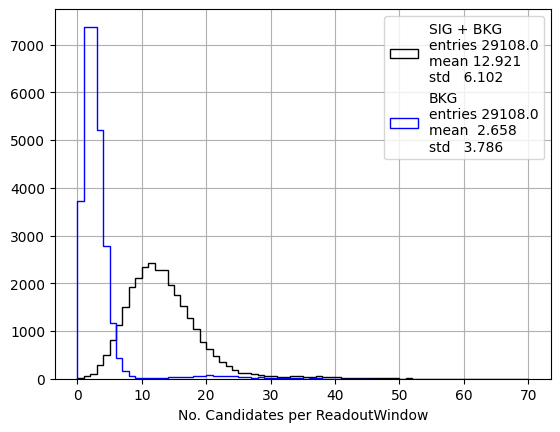

In [68]:
# 2. Cuántos candidatos hay en una readout window?
candidates_per_redaoutWindow_sig = []
for k,v in nicf_triggered_signal_hit_times_tof.items():
    candidates_per_redaoutWindow_sig.append(len(v))

candidates_per_redaoutWindow_bkg = []
for k,v in bkg_triggered_signal_hit_times_tof.items():
    candidates_per_redaoutWindow_bkg.append(len(v))

pltext.hist(candidates_per_redaoutWindow_sig, np.max(candidates_per_redaoutWindow_sig), xylabels="No. Candidates per ReadoutWindow", label="SIG + BKG");
pltext.hist(candidates_per_redaoutWindow_bkg, np.max(candidates_per_redaoutWindow_bkg), xylabels="No. Candidates per ReadoutWindow", label="BKG");

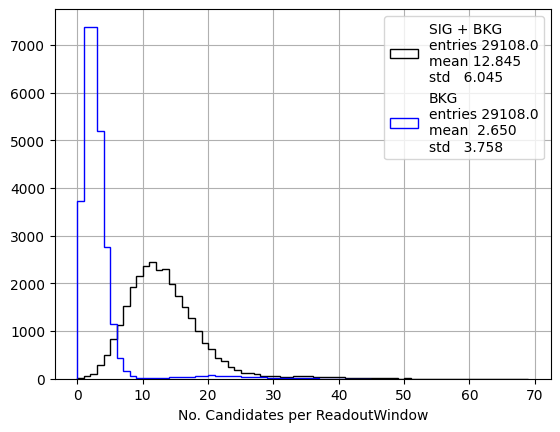

In [69]:
# 2. Cuántos candidatos hay en una readout window?
candidates_per_redaoutWindow_sig_clean = []
for k,v in nicf_triggered_signal_hit_times_tof_clean.items():
    candidates_per_redaoutWindow_sig_clean.append(len(v))

candidates_per_redaoutWindow_bkg_clean = []
for k,v in bkg_triggered_signal_hit_times_tof_clean.items():
    candidates_per_redaoutWindow_bkg_clean.append(len(v))

pltext.hist(candidates_per_redaoutWindow_sig_clean, np.max(candidates_per_redaoutWindow_sig_clean), xylabels="No. Candidates per ReadoutWindow", label="SIG + BKG");
pltext.hist(candidates_per_redaoutWindow_bkg_clean, np.max(candidates_per_redaoutWindow_bkg_clean), xylabels="No. Candidates per ReadoutWindow", label="BKG");

# $t_c$, $t_{RMS}$ and nHits In The Small Sliding Window

### Plots, Non PDFs

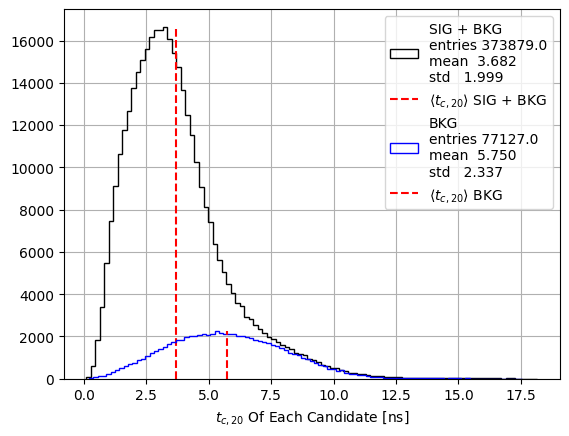

In [70]:
# 1. Calcular el tc de ese candidato como el promedio del tiempo de sus hits (los que están en la venta).

tc_20_sig = []
for k,v in nicf_triggered_signal_hit_times_tof_clean.items():
    event = k
    sett  = nicf_triggered_signal_hit_times_tof_clean[event] 
    seed  = nicf_d_seed_tof_clean[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask  = (shifted_sett >= shifted_seed) & (shifted_sett <= shifted_seed+20)
        mean_val = np.mean(shifted_sett[mask]) if len(shifted_sett[mask]) > 0 else None

        if mean_val is not None:
            tc_20_sig.append(mean_val)

tc_20_bkg = []
for k,v in bkg_triggered_signal_hit_times_tof_clean.items():
    event = k
    sett  = bkg_triggered_signal_hit_times_tof_clean[event] 
    seed  = bkg_d_seed_tof_clean[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask  = (shifted_sett >= shifted_seed) & (shifted_sett < shifted_seed+20)
        mean_val = np.mean(shifted_sett[mask]) if len(shifted_sett[mask]) > 0 else None

        if mean_val is not None:
            tc_20_bkg.append(mean_val)

h = pltext.hist(tc_20_sig, 100, ylog=False, xylabels="$t_{c, 20}$ Of Each Candidate [ns]", label="SIG + BKG");
plt.vlines(np.mean(tc_20_sig), 0, np.max(h[0]), color="red", linestyles="--", label=r"$\langle t_{c, 20} \rangle$ SIG + BKG");
h = pltext.hist(tc_20_bkg, 100, ylog=False, xylabels="$t_{c, 20}$ Of Each Candidate [ns]", label="BKG");
plt.vlines(np.mean(tc_20_bkg), 0, np.max(h[0]), color="red", linestyles="--", label=r"$\langle t_{c, 20} \rangle$ BKG");
plt.legend();

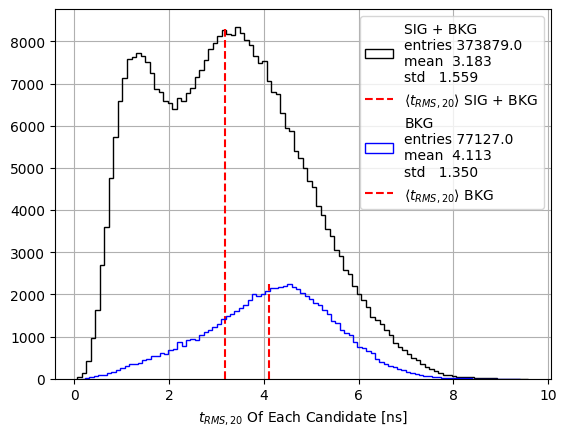

In [71]:
trms_20_sig = []
for k,v in nicf_triggered_signal_hit_times_tof_clean.items():
    event = k
    sett  = nicf_triggered_signal_hit_times_tof_clean[event] 
    seed  = nicf_d_seed_tof_clean[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask  = (shifted_sett >= shifted_seed) & (shifted_sett <= shifted_seed+20)
        std_val = np.std(shifted_sett[mask]) if len(shifted_sett[mask]) > 0 else None

        if std_val is not None:
            trms_20_sig.append(std_val)

trms_20_bkg = []
for k,v in bkg_triggered_signal_hit_times_tof_clean.items():
    event = k
    sett  = bkg_triggered_signal_hit_times_tof_clean[event] 
    seed  = bkg_d_seed_tof_clean[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask  = (shifted_sett >= shifted_seed) & (shifted_sett < shifted_seed+20)
        std_val = np.std(shifted_sett[mask]) if len(shifted_sett[mask]) > 0 else None

        if std_val is not None:
            trms_20_bkg.append(std_val)

h = pltext.hist(trms_20_sig, 100, ylog=False, xylabels="$t_{RMS, 20}$ Of Each Candidate [ns]", label="SIG + BKG");
plt.vlines(np.mean(trms_20_sig), 0, np.max(h[0]), color="red", linestyles="--", label=r"$\langle t_{RMS, 20} \rangle$ SIG + BKG");
h = pltext.hist(trms_20_bkg, 100, ylog=False, xylabels="$t_{RMS, 20}$ Of Each Candidate [ns]", label="BKG");
plt.vlines(np.mean(trms_20_bkg), 0, np.max(h[0]), color="red", linestyles="--", label=r"$\langle t_{RMS, 20} \rangle$ BKG");
plt.legend();

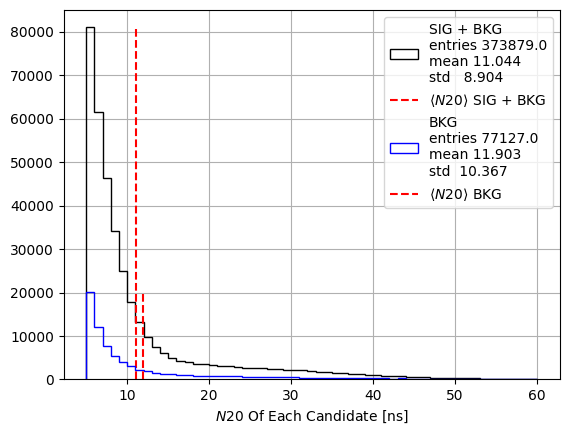

In [72]:
nhits_sig = []
for k,v in nicf_triggered_signal_hit_times_tof_clean.items():
    event = k
    sett  = nicf_triggered_signal_hit_times_tof_clean[event] 
    seed  = nicf_d_seed_tof_clean[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask  = (shifted_sett >= shifted_seed) & (shifted_sett <= shifted_seed+20)
        nhits_val = len(shifted_sett[mask]) if len(shifted_sett[mask]) > 0 else None

        if nhits_val is not None:
            nhits_sig.append(nhits_val)

nhits_bkg = []
for k,v in bkg_triggered_signal_hit_times_tof_clean.items():
    event = k
    sett  = bkg_triggered_signal_hit_times_tof_clean[event] 
    seed  = bkg_d_seed_tof_clean[event]

    for i in range(len(sett)):

        shifted_sett = sett[i] - seed[i]
        shifted_seed = seed[i] - seed[i]

        mask  = (shifted_sett >= shifted_seed) & (shifted_sett <= shifted_seed+20)
        nhits_val = len(shifted_sett[mask]) if len(shifted_sett[mask]) > 0 else None

        if nhits_val is not None:
            nhits_bkg.append(nhits_val)

h = pltext.hist(nhits_sig, 55, ylog=False, xylabels="$N20$ Of Each Candidate [ns]", label="SIG + BKG");
plt.vlines(np.mean(nhits_sig), 0, np.max(h[0]), color="red", linestyles="--", label=r"$\langle N20 \rangle$ SIG + BKG");
h = pltext.hist(nhits_bkg, 55, ylog=False, xylabels="$N20$ Of Each Candidate [ns]", label="BKG");
plt.vlines(np.mean(nhits_bkg), 0, np.max(h[0]), color="red", linestyles="--", label=r"$\langle N20 \rangle$ BKG");
plt.legend();

### $t_c$, $t_{RMS}$ and nHits As PDFs

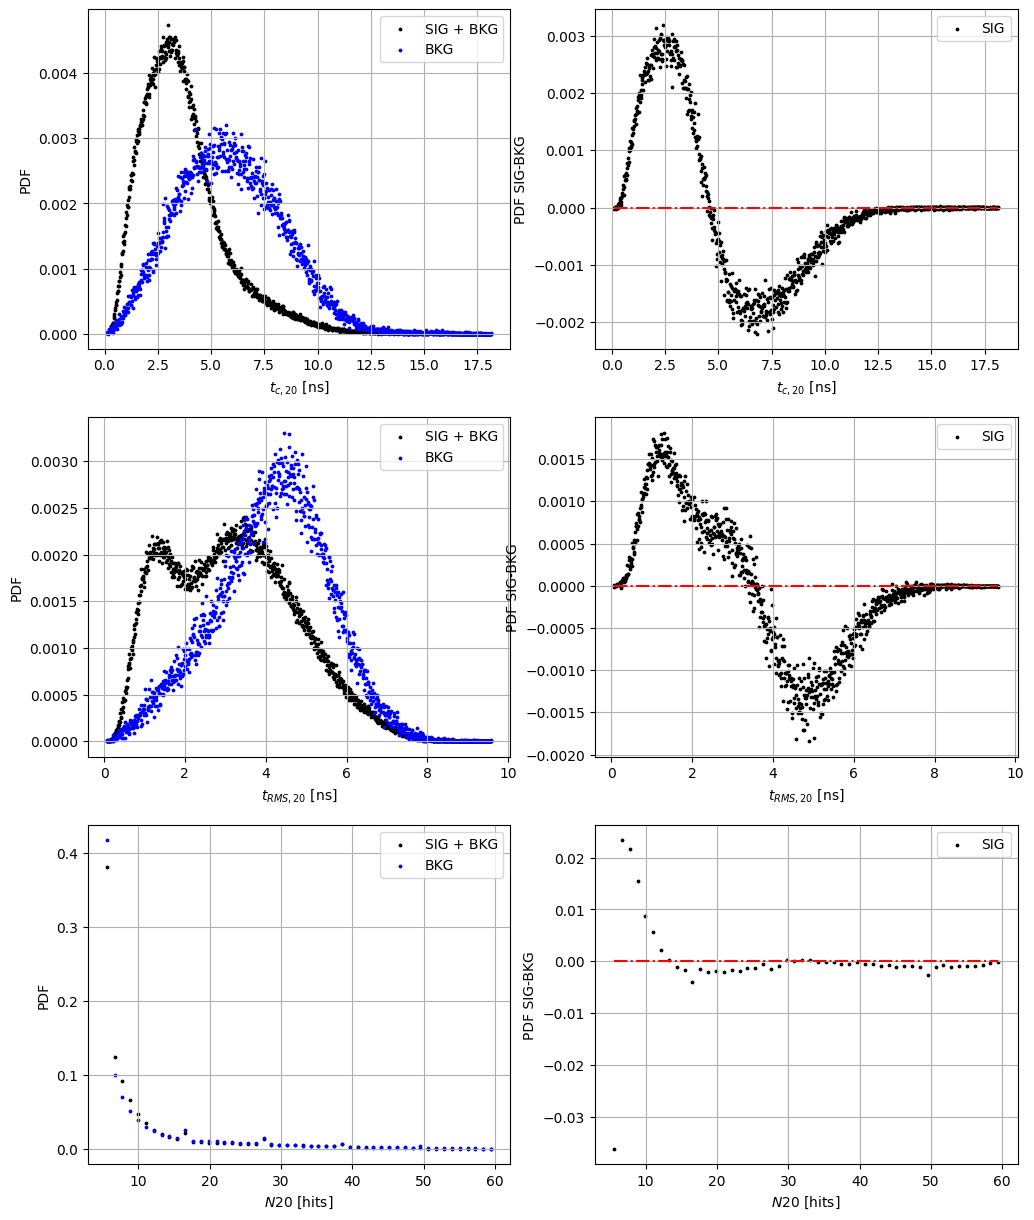

In [73]:
subplot = pltext.canvas(6)
###################################
# tc
###################################
hs = np.histogram(tc_20_sig, 1000);
hb = np.histogram(tc_20_bkg, 1000);

# Calculamos los centros de los bins
bin_centers = (hs[1][:-1] + hs[1][1:]) / 2

subplot(1)
plt.scatter(bin_centers, hs[0]/np.sum(hs[0]), s=3, label="SIG + BKG")
plt.scatter(bin_centers, hb[0]/np.sum(hb[0]), s=3, label="BKG")
plt.xlabel("$t_{c, 20}$ [ns]")
plt.ylabel("PDF")
plt.grid(True)
plt.legend()

subplot(2)
sub = (hs[0]/np.sum(hs[0])) - (hb[0]/np.sum(hb[0]))
plt.scatter(bin_centers, sub, s=3, label="SIG")
plt.hlines(0, bin_centers[0], bin_centers[-1], linestyles="-.", color="red")
plt.xlabel("$t_{c, 20}$ [ns]")
plt.grid(True);
plt.ylabel("PDF SIG-BKG");
plt.legend();

###################################
# trms
###################################
hs = np.histogram(trms_20_sig, 1000);
hb = np.histogram(trms_20_bkg, 1000);

# Calculamos los centros de los bins
bin_centers = (hs[1][:-1] + hs[1][1:]) / 2

subplot(3)
plt.scatter(bin_centers, hs[0]/np.sum(hs[0]), s=3, label="SIG + BKG")
plt.scatter(bin_centers, hb[0]/np.sum(hb[0]), s=3, label="BKG")
plt.xlabel("$t_{RMS, 20}$ [ns]")
plt.ylabel("PDF")
plt.grid(True)
plt.legend()

subplot(4)
sub = (hs[0]/np.sum(hs[0])) - (hb[0]/np.sum(hb[0]))
plt.scatter(bin_centers, sub, s=3, label="SIG")
plt.hlines(0, bin_centers[0], bin_centers[-1], linestyles="-.", color="red")
plt.xlabel("$t_{RMS, 20}$ [ns]")
plt.grid(True);
plt.ylabel("PDF SIG-BKG");
plt.legend();

###################################
# nhits
###################################
hs = np.histogram(nhits_sig, 50);
hb = np.histogram(nhits_bkg, 50);

# Calculamos los centros de los bins
bin_centers = (hs[1][:-1] + hs[1][1:]) / 2

subplot(5)
plt.scatter(bin_centers, hs[0]/np.sum(hs[0]), s=3, label="SIG + BKG")
plt.scatter(bin_centers, hb[0]/np.sum(hb[0]), s=3, label="BKG")
plt.xlabel("$N20$ [hits]")
plt.ylabel("PDF")
plt.grid(True)
plt.legend()

subplot(6)
sub = (hs[0]/np.sum(hs[0])) - (hb[0]/np.sum(hb[0]))
plt.scatter(bin_centers, sub, s=3, label="SIG")
plt.hlines(0, bin_centers[0], bin_centers[-1], linestyles="-.", color="red")
plt.xlabel("$N20$ [hits]")
plt.grid(True);
plt.ylabel("PDF SIG-BKG");
plt.legend();

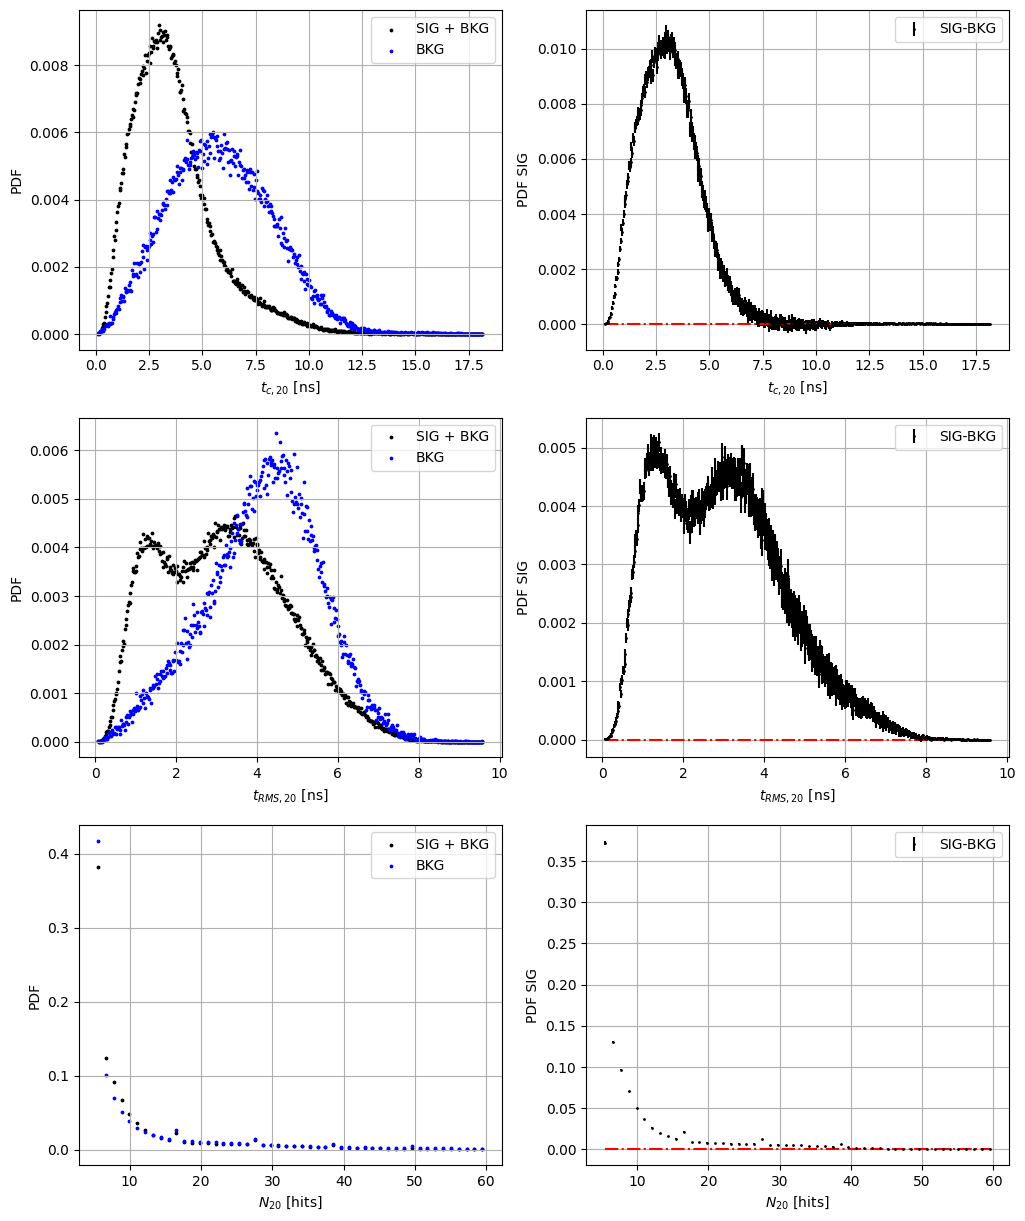

In [74]:
def plot_pdf_with_sub(sig_list, bkg_list, bins, xlabel, subplot_idx):
    subplot(subplot_idx)  # activa la subventana
    hs = np.histogram(sig_list, bins=bins)
    hb = np.histogram(bkg_list, bins=bins)
    
    bin_centers = (hs[1][:-1] + hs[1][1:]) / 2
    pdf_sig = hs[0] / np.sum(hs[0])
    pdf_bkg = hb[0] / np.sum(hb[0])

    # Errores Poisson
    err_sig = np.sqrt(hs[0]) / np.sum(hs[0])
    err_bkg = np.sqrt(hb[0]) / np.sum(hb[0])

    # PDF SIG/BKG
    plt.scatter(bin_centers, pdf_sig, s=3, label="SIG + BKG")
    plt.scatter(bin_centers, pdf_bkg, s=3, label="BKG")
    plt.xlabel(xlabel)
    plt.ylabel("PDF")
    plt.grid(True)
    # plt.yscale("log")
    plt.legend()

    # Diferencia SIG-BKG
    subplot(subplot_idx + 1)
    diff = (pdf_sig - pdf_bkg*0.2)/0.8
    diff_err = np.sqrt((err_sig)**2 + (err_bkg)**2)
    plt.errorbar(bin_centers, diff, yerr=diff_err, fmt='o', markersize=1, label="SIG-BKG")
    plt.hlines(0, bin_centers[0], bin_centers[-1], linestyles="-.", color="red")
    plt.xlabel(xlabel)
    plt.ylabel("PDF SIG")
    plt.grid(True)
    # plt.yscale("log")
    plt.legend()

    return bin_centers, pdf_sig, pdf_bkg

subplot = pltext.canvas(6)  # 3 variables × 2 subplots cada una
bin_centers_tc, pdf_sig_tc, pdf_bkg_tc          = plot_pdf_with_sub(tc_20_sig, tc_20_bkg, 500, "$t_{c, 20}$ [ns]", 1)
bin_centers_trms, pdf_sig_trms, pdf_bkg_trms    = plot_pdf_with_sub(trms_20_sig, trms_20_bkg, 500, "$t_{RMS, 20}$ [ns]", 3)
bin_centers_nhits, pdf_sig_nhits, pdf_bkg_nhits = plot_pdf_with_sub(nhits_sig, nhits_bkg, 50, "$N_{20}$ [hits]", 5)

# tRMS As A Function Of The Inferior Trigger Threshold

100%|██████████| 11/11 [11:19<00:00, 61.80s/it]


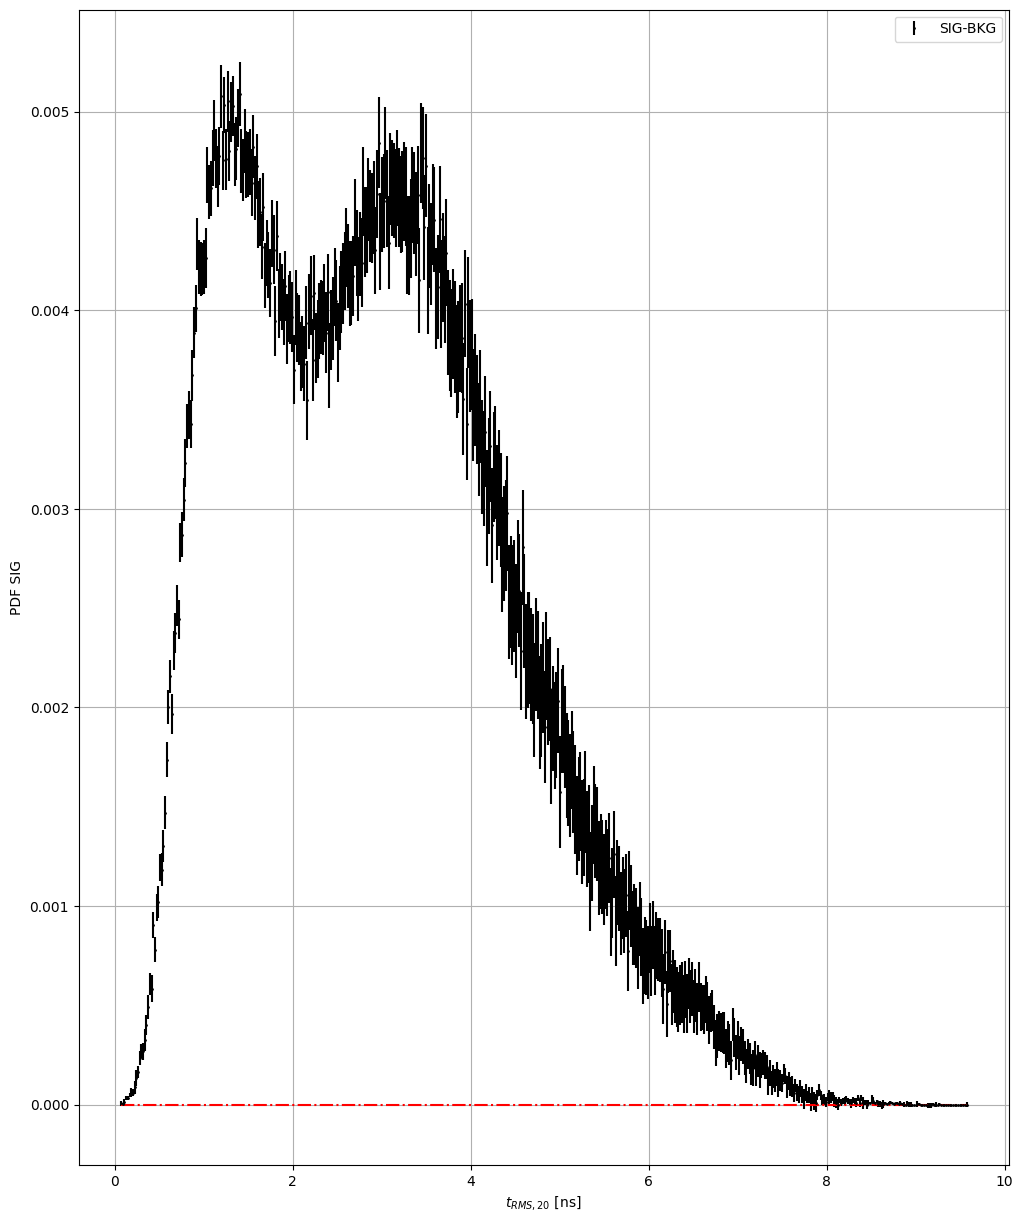

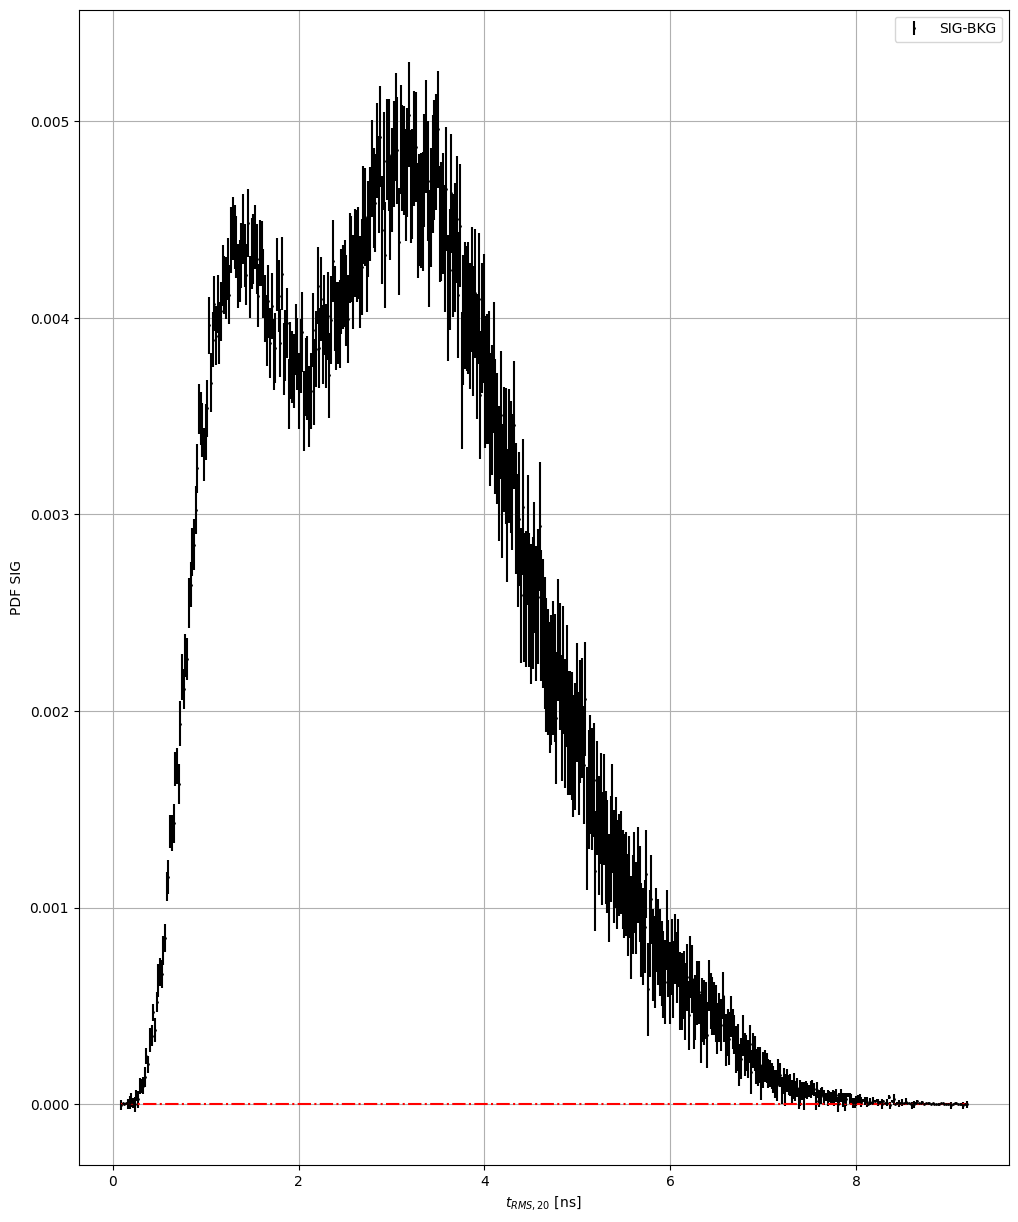

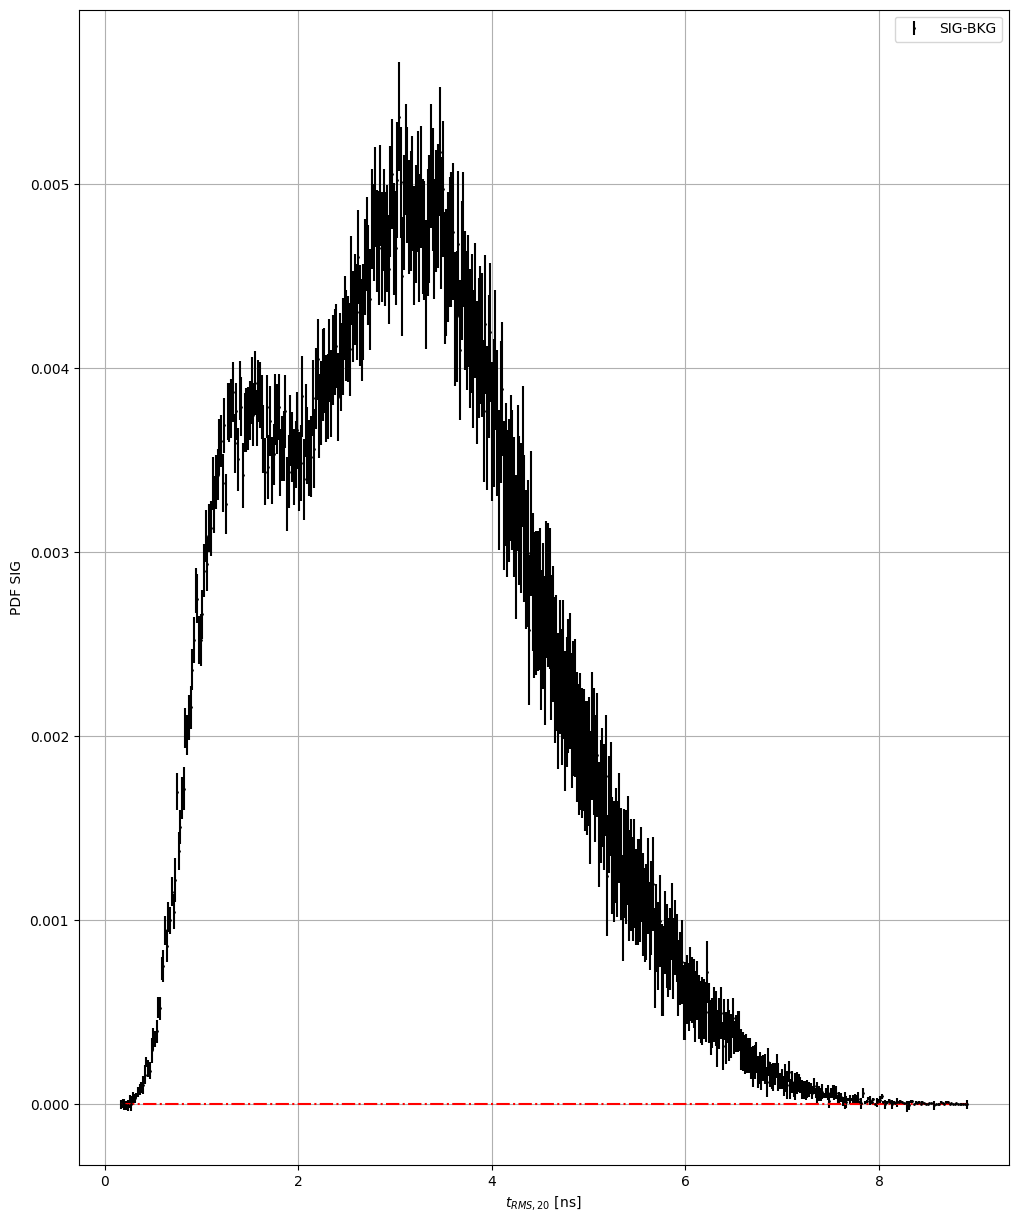

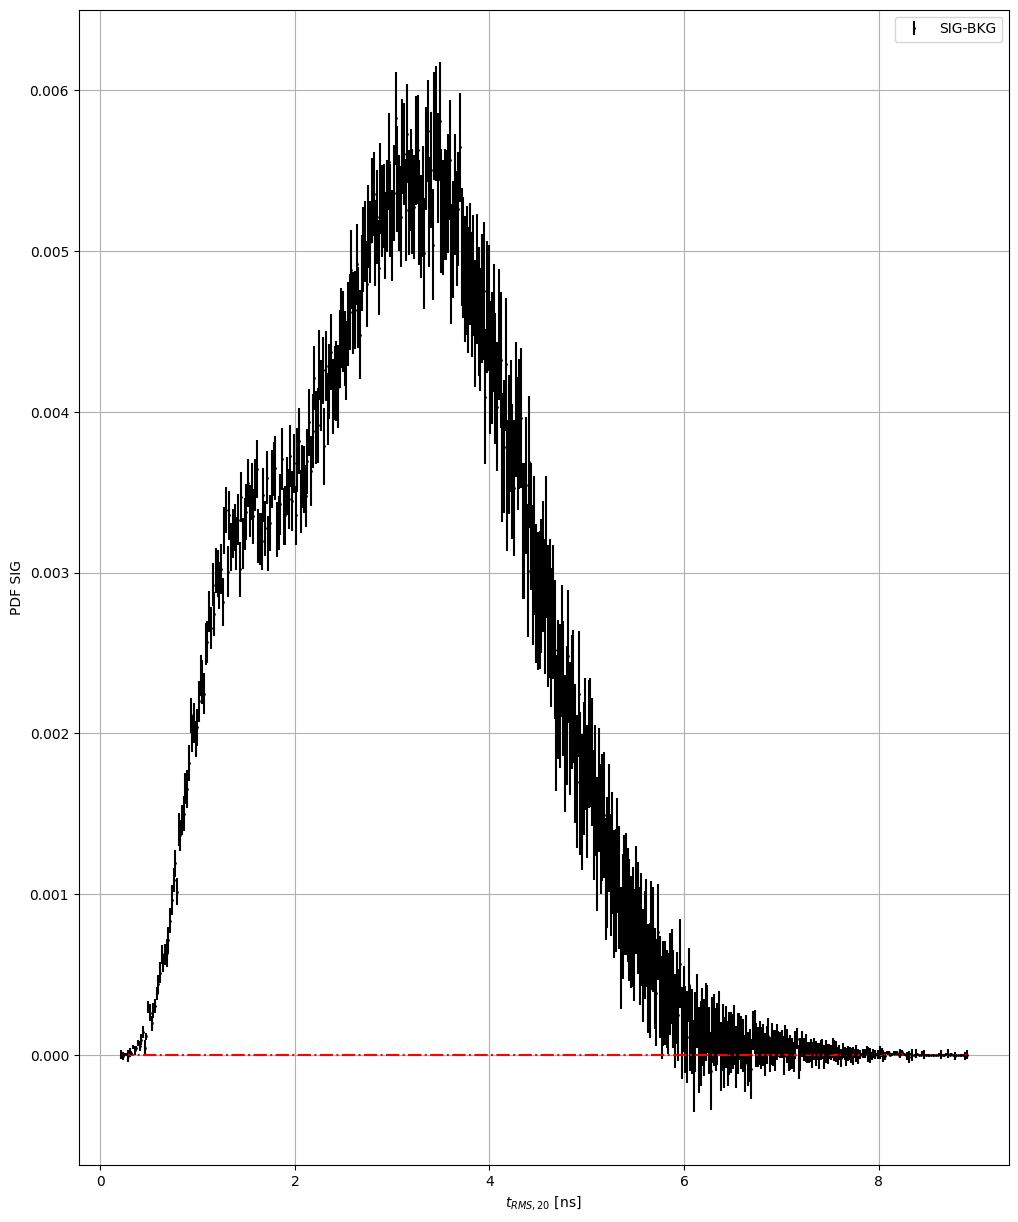

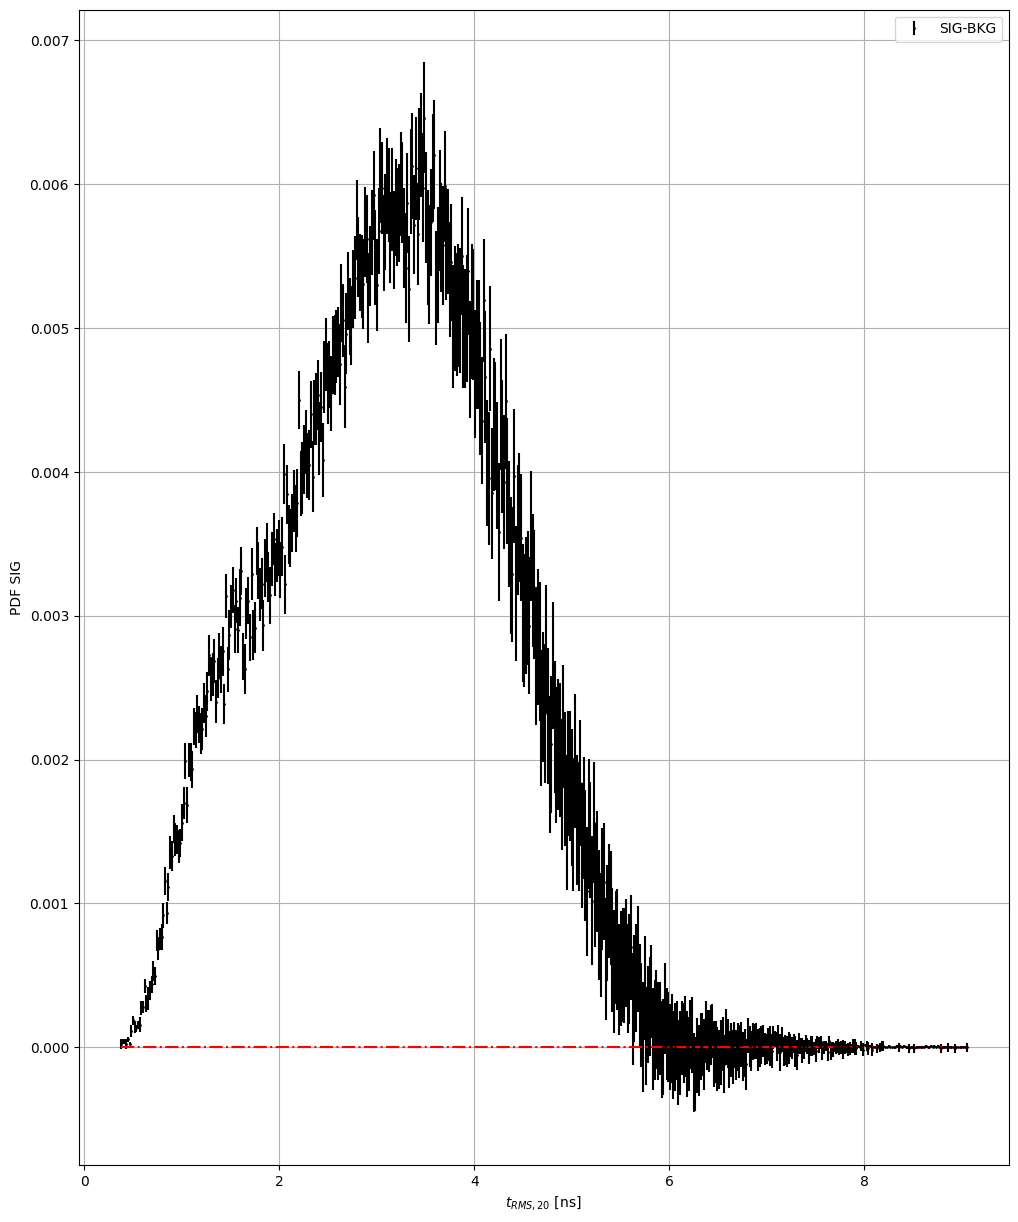

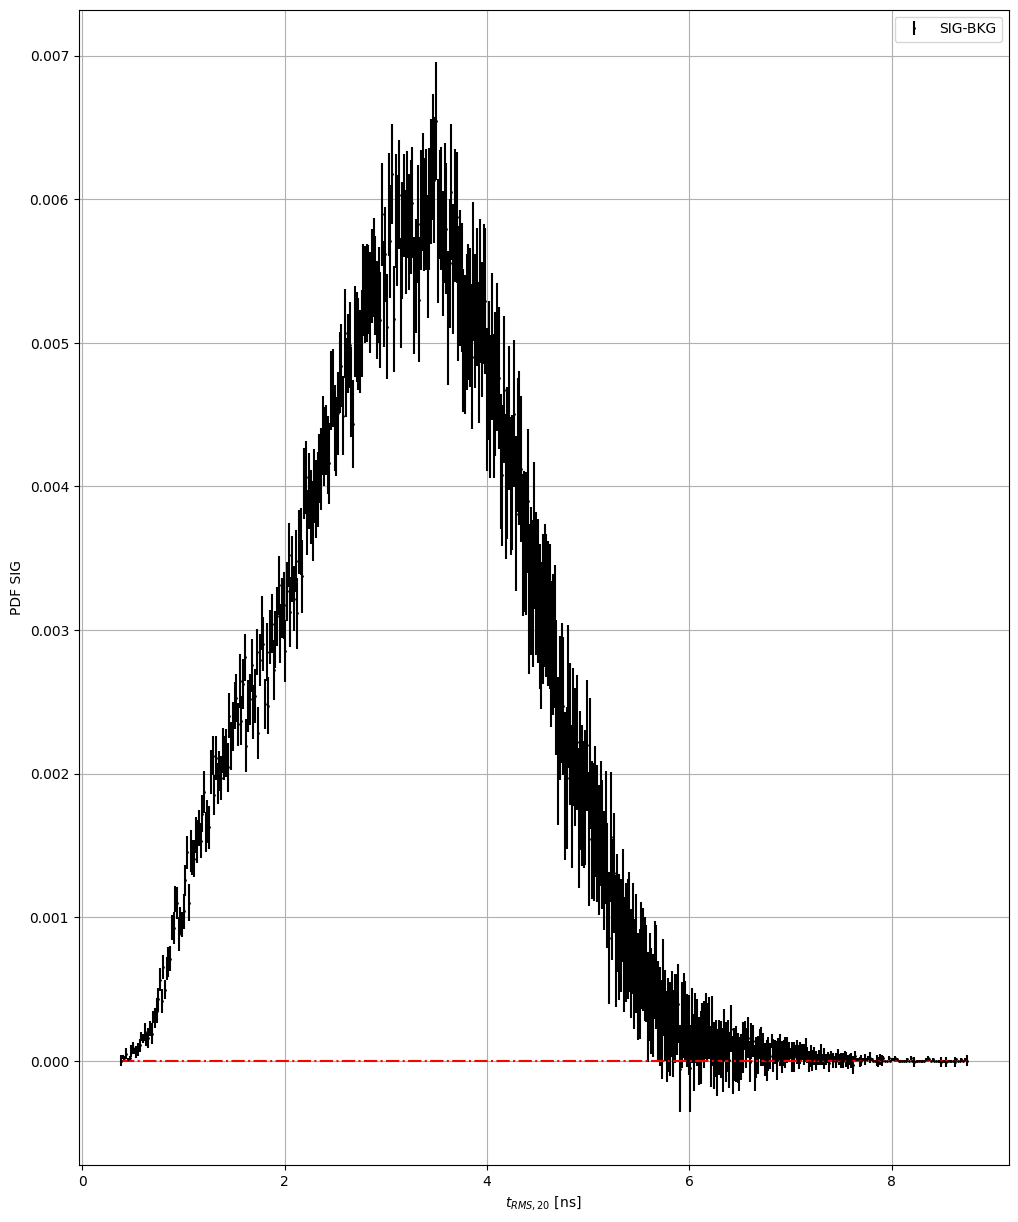

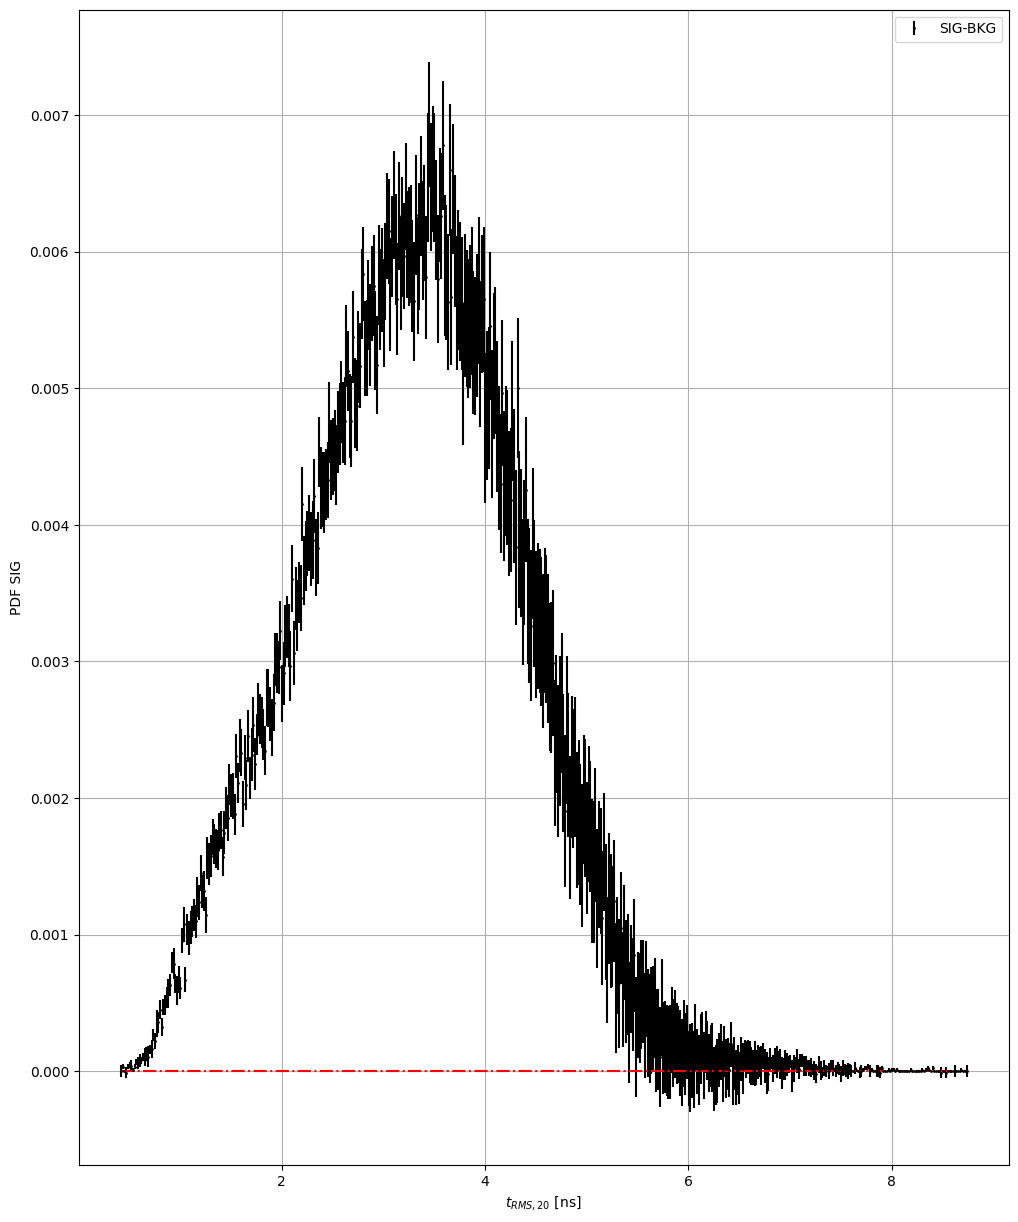

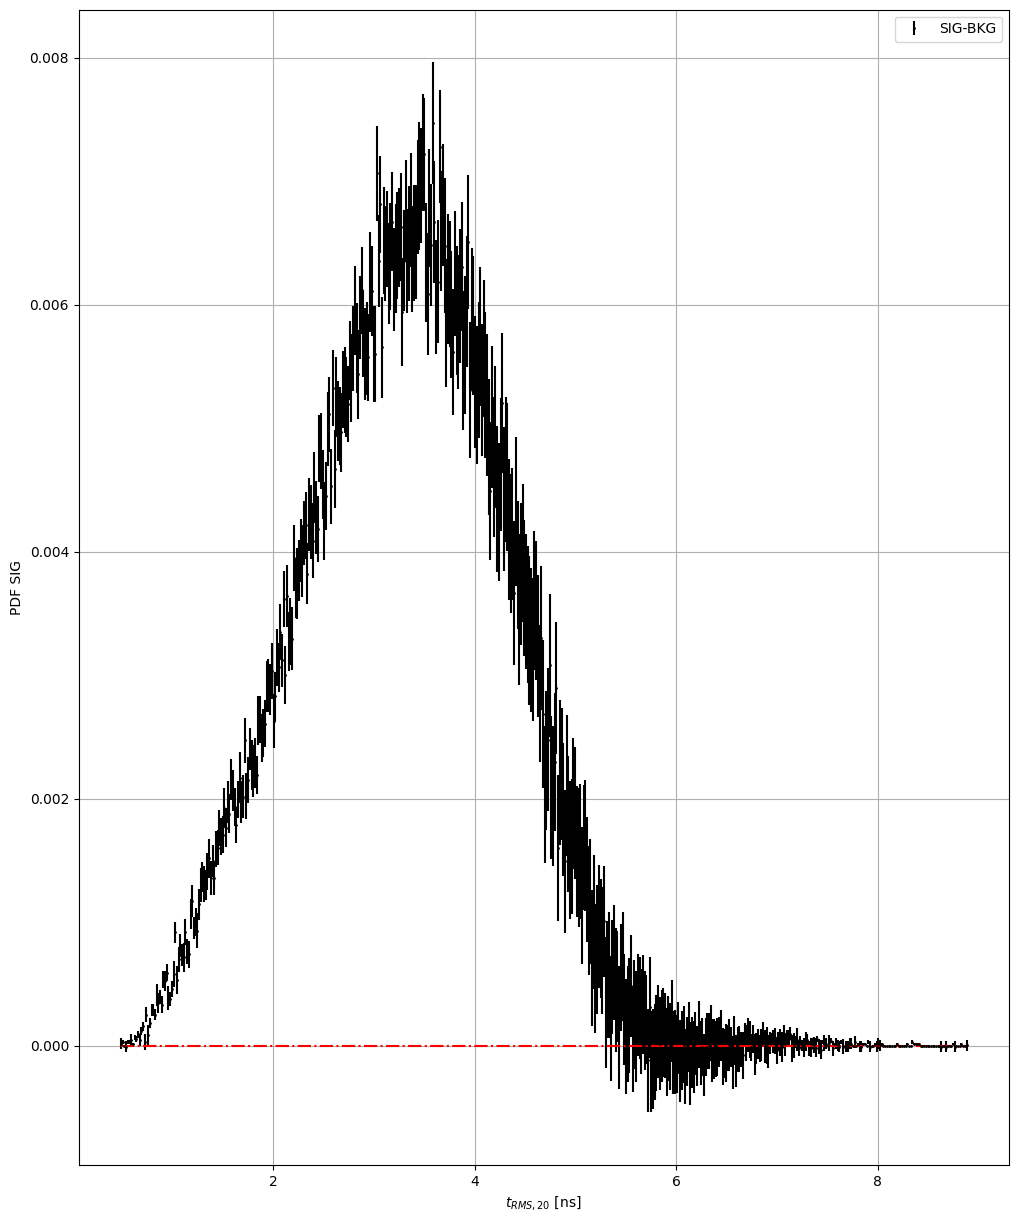

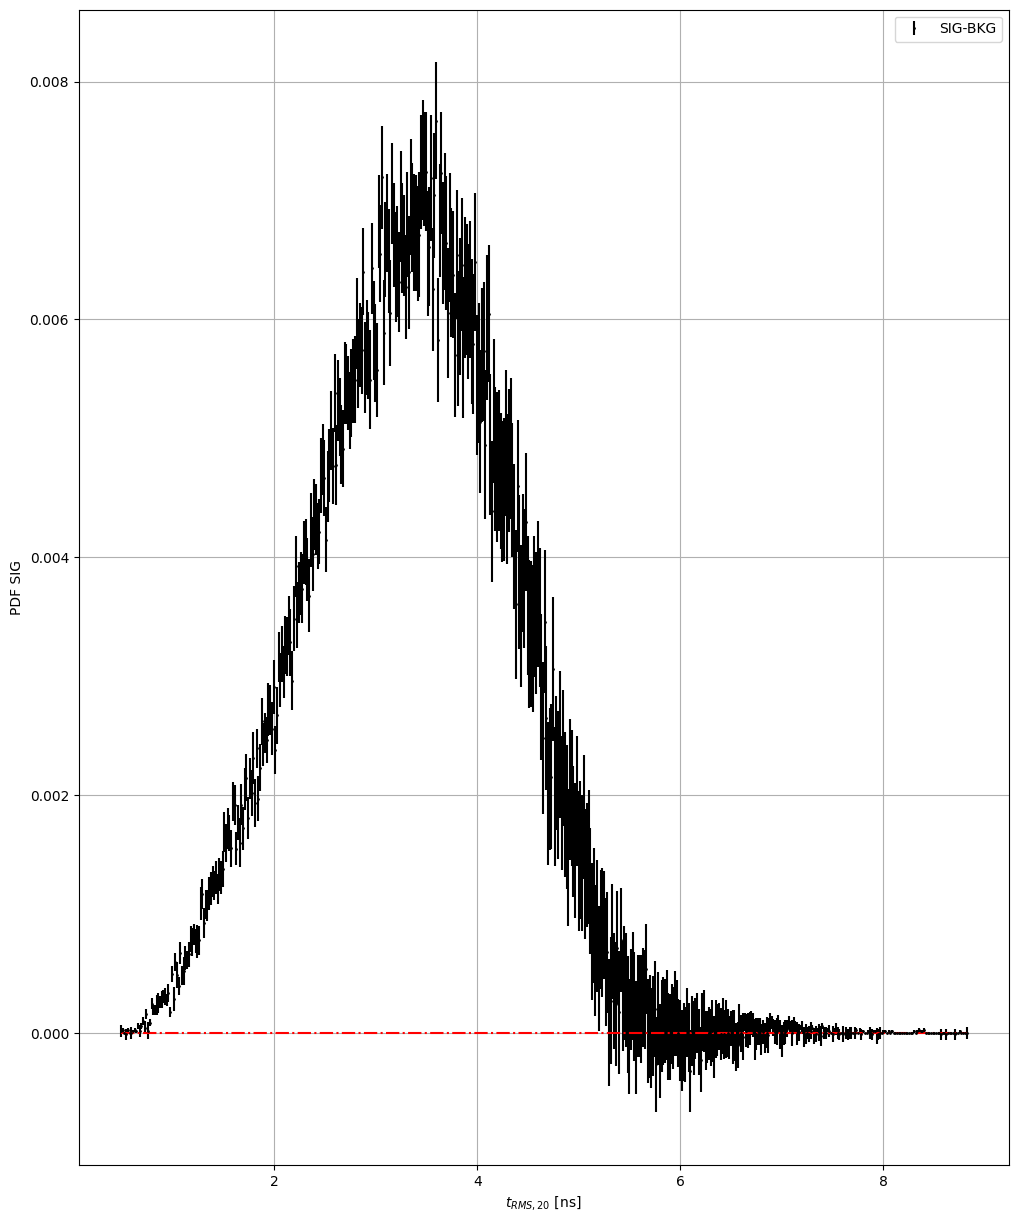

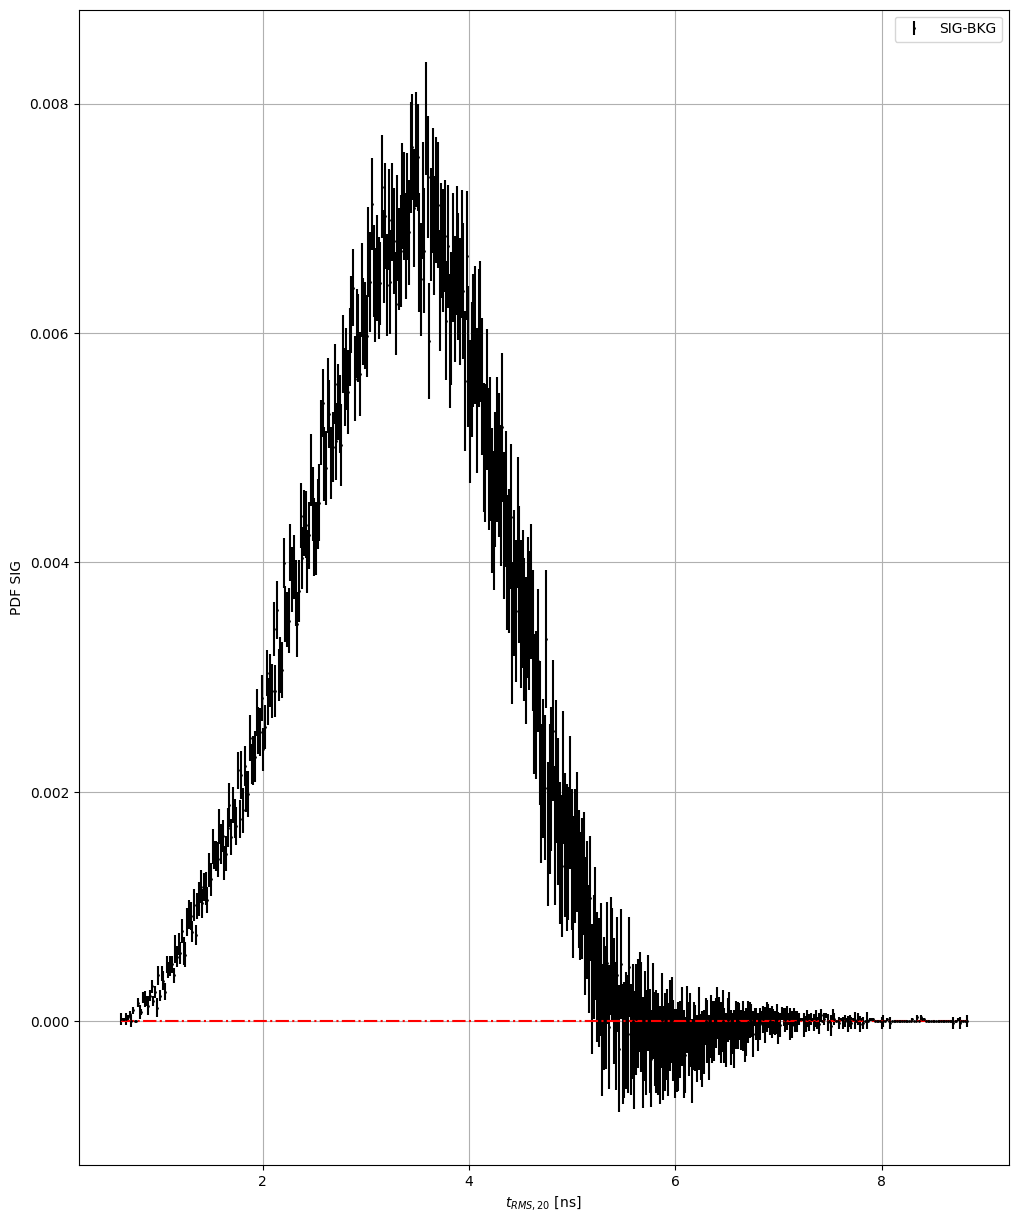

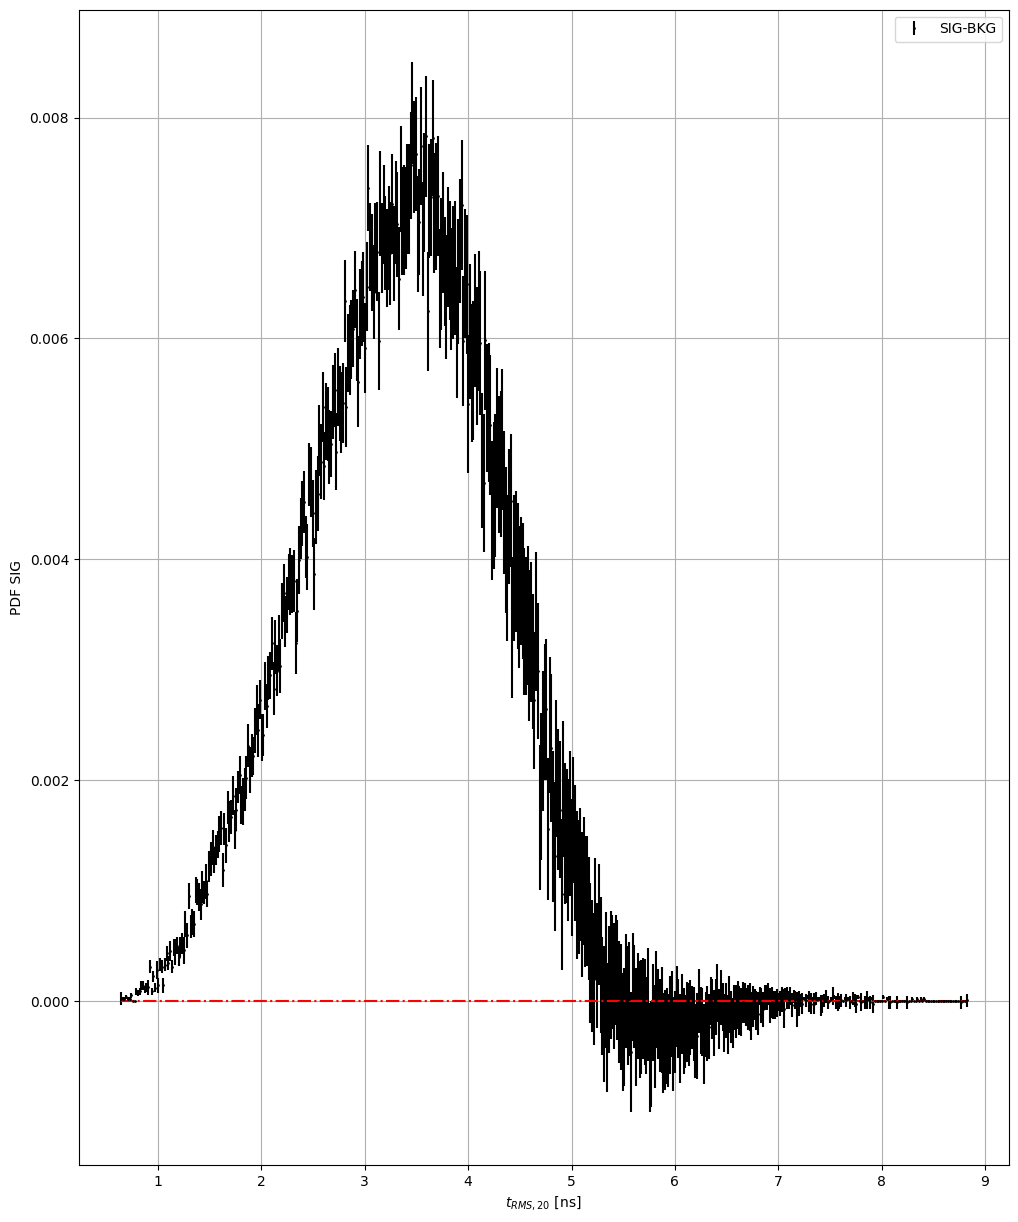

In [35]:
from copy import deepcopy
from collections import defaultdict

trms_sigPDF_values = []

for i in tqdm([5,6,7,8,9,10,11,12,13,14,15], total=11):
    thresh_inf          = i   # hits
    thresh_sup          = 60   # hits
    sliding_window      = 20   # ns
    pre_trigger_window  = 200
    post_trigger_window = 200
    dead_time           = pre_trigger_window + post_trigger_window    # ns

    # nHits
    nicf_triggered_signal_hits_index_tof, nicf_triggered_signal_hit_times_tof, nicf_d_seed_tof, nicf_d_roi_tof = nHits(mode="multiple_events", hit_times=nicf_noSpill_times_tof, w=sliding_window, thresh_min=thresh_inf, thresh_max=thresh_sup, pre_window=pre_trigger_window, post_window=post_trigger_window, jump=dead_time)
    bkg_triggered_signal_hits_index_tof, bkg_triggered_signal_hit_times_tof, bkg_d_seed_tof, bkg_d_roi_tof     = nHits(mode="multiple_events", hit_times=bkg_noSpill_times,      w=sliding_window, thresh_min=thresh_inf, thresh_max=thresh_sup, pre_window=pre_trigger_window, post_window=post_trigger_window, jump=dead_time)

    # Eliminamos ese candidato si en la ventana extendida [200, 20 + 200] hay alguna otra acumulación de hits > 10 en 20 ns 
    # (que podemos llamar flash). Esto es en la ventana extendida solo está ese candidado con >10 hits 

    doubleCandidates_sig = {}

    for k,v in tqdm(nicf_triggered_signal_hit_times_tof.items(), total=len(nicf_triggered_signal_hit_times_tof.items()), leave=False):
        event = k
        sett  = nicf_triggered_signal_hit_times_tof[event] 
        seed  = nicf_d_seed_tof[event]
        roi   = nicf_d_roi_tof[event]
        for c in range(len(v)):
            
            candidate_to_investigate = [sett[c] - seed[c]]
            thresh_inf               = 5     # hits
            thresh_sup               = np.inf # hits
            sliding_window           = 20     # ns
            pre_trigger_window       = 0      # ns  
            post_trigger_window      = 0      # ns
            dead_time                = sliding_window + post_trigger_window

            test_triggered_signal_hits_index_tof, test_triggered_signal_hit_times_tof, test_d_seed_tof, test_d_roi_tof = nHits(mode="single_event", hit_times=candidate_to_investigate, w=sliding_window, thresh_min=thresh_inf, thresh_max=thresh_sup, pre_window=pre_trigger_window, post_window=post_trigger_window, jump=dead_time, event=0)

            if len(test_triggered_signal_hit_times_tof[0]) > 1:
                # print(k, c, ":", len(test_triggered_signal_hit_times_tof[0]))
                doubleCandidates_sig[k] = c

    doubleCandidates_bkg = {}

    for k,v in tqdm(bkg_triggered_signal_hit_times_tof.items(), total=len(bkg_triggered_signal_hit_times_tof.items()), leave=False):
        event = k
        sett  = bkg_triggered_signal_hit_times_tof[event] 
        seed  = bkg_d_seed_tof[event]
        roi   = bkg_d_roi_tof[event]
        for c in range(len(v)):
            
            candidate_to_investigate = [sett[c] - seed[c]]
            thresh_inf               = 5     # hits
            thresh_sup               = np.inf # hits
            sliding_window           = 20     # ns
            pre_trigger_window       = 0      # ns  
            post_trigger_window      = 0      # ns
            dead_time                = sliding_window + post_trigger_window

            test_triggered_signal_hits_index_tof, test_triggered_signal_hit_times_tof, test_d_seed_tof, test_d_roi_tof = nHits(mode="single_event", hit_times=candidate_to_investigate, w=sliding_window, thresh_min=thresh_inf, thresh_max=thresh_sup, pre_window=pre_trigger_window, post_window=post_trigger_window, jump=dead_time, event=0)

            if len(test_triggered_signal_hit_times_tof[0]) > 1:
                # print(k, c, ":", len(test_triggered_signal_hit_times_tof[0]))
                doubleCandidates_bkg[k] = c

    nicf_triggered_signal_hit_times_tof_clean  = deepcopy(nicf_triggered_signal_hit_times_tof)
    nicf_d_seed_tof_clean                      = deepcopy(nicf_d_seed_tof)
    nicf_triggered_signal_hits_index_tof_clean = deepcopy(nicf_triggered_signal_hits_index_tof)

    to_delete = defaultdict(list)
    for k, idx in doubleCandidates_sig.items():
        to_delete[k].append(idx)

    for k, indices in to_delete.items():
        for idx in sorted(indices, reverse=True):
            if k in nicf_triggered_signal_hit_times_tof_clean and idx < len(nicf_triggered_signal_hit_times_tof_clean[k]):
                del nicf_triggered_signal_hit_times_tof_clean[k][idx]
                del nicf_d_seed_tof_clean[k][idx]
                del nicf_triggered_signal_hits_index_tof_clean[k][idx]

    bkg_triggered_signal_hit_times_tof_clean  = deepcopy(bkg_triggered_signal_hit_times_tof)
    bkg_d_seed_tof_clean                      = deepcopy(bkg_d_seed_tof)
    bkg_triggered_signal_hits_index_tof_clean = deepcopy(bkg_triggered_signal_hits_index_tof)

    to_delete = defaultdict(list)
    for k, idx in doubleCandidates_bkg.items():
        to_delete[k].append(idx)

    for k, indices in to_delete.items():
        for idx in sorted(indices, reverse=True):
            if k in bkg_triggered_signal_hit_times_tof_clean and idx < len(bkg_triggered_signal_hit_times_tof_clean[k]):
                del bkg_triggered_signal_hit_times_tof_clean[k][idx]
                del bkg_d_seed_tof_clean[k][idx]
                del bkg_triggered_signal_hits_index_tof_clean[k][idx]

    trms_20_sig = []
    for k,v in nicf_triggered_signal_hit_times_tof_clean.items():
        event = k
        sett  = nicf_triggered_signal_hit_times_tof_clean[event] 
        seed  = nicf_d_seed_tof_clean[event]

        for i in range(len(sett)):

            shifted_sett = sett[i] - seed[i]
            shifted_seed = seed[i] - seed[i]

            mask  = (shifted_sett >= shifted_seed) & (shifted_sett <= shifted_seed+20)
            std_val = np.std(shifted_sett[mask]) if len(shifted_sett[mask]) > 0 else None

            if std_val is not None:
                trms_20_sig.append(std_val)

    trms_20_bkg = []
    for k,v in bkg_triggered_signal_hit_times_tof_clean.items():
        event = k
        sett  = bkg_triggered_signal_hit_times_tof_clean[event] 
        seed  = bkg_d_seed_tof_clean[event]

        for i in range(len(sett)):

            shifted_sett = sett[i] - seed[i]
            shifted_seed = seed[i] - seed[i]

            mask  = (shifted_sett >= shifted_seed) & (shifted_sett < shifted_seed+20)
            std_val = np.std(shifted_sett[mask]) if len(shifted_sett[mask]) > 0 else None

            if std_val is not None:
                trms_20_bkg.append(std_val)

    def plot_pdf_with_sub(sig_list, bkg_list, bins, xlabel, subplot_idx):
        # subplot(subplot_idx)  # activa la subventana
        hs = np.histogram(sig_list, bins=bins)
        hb = np.histogram(bkg_list, bins=bins)
        
        bin_centers = (hs[1][:-1] + hs[1][1:]) / 2
        pdf_sig = hs[0] / np.sum(hs[0])
        pdf_bkg = hb[0] / np.sum(hb[0])

        # Errores Poisson
        err_sig = np.sqrt(hs[0]) / np.sum(hs[0])
        err_bkg = np.sqrt(hb[0]) / np.sum(hb[0])

        # PDF SIG/BKG
        # plt.scatter(bin_centers, pdf_sig, s=3, label="SIG + BKG")
        # plt.scatter(bin_centers, pdf_bkg, s=3, label="BKG")
        # plt.xlabel(xlabel)
        # plt.ylabel("PDF")
        # plt.grid(True)
        # # plt.yscale("log")
        # plt.legend()

        # Diferencia SIG-BKG
        # subplot(subplot_idx + 1)
        diff = (pdf_sig - pdf_bkg*0.2)/0.8
        diff_err = np.sqrt((err_sig)**2 + (err_bkg)**2)
        plt.errorbar(bin_centers, diff, yerr=diff_err, fmt='o', markersize=1, label="SIG-BKG")
        plt.hlines(0, bin_centers[0], bin_centers[-1], linestyles="-.", color="red")
        plt.xlabel(xlabel)
        plt.ylabel("PDF SIG")
        plt.grid(True)
        # plt.yscale("log")
        plt.legend()

        return bin_centers, pdf_sig, pdf_bkg

    subplot = pltext.canvas(6)  # 3 variables × 2 subplots cada una
    # bin_centers_tc, pdf_sig_tc, pdf_bkg_tc          = plot_pdf_with_sub(tc_20_sig, tc_20_bkg, 500, "$t_{c, 20}$ [ns]", 1)
    bin_centers_trms, pdf_sig_trms, pdf_bkg_trms    = plot_pdf_with_sub(trms_20_sig, trms_20_bkg, 500, "$t_{RMS, 20}$ [ns]", 3)
    # bin_centers_nhits, pdf_sig_nhits, pdf_bkg_nhits = plot_pdf_with_sub(nhits_sig, nhits_bkg, 50, "$N_{20}$ [hits]", 5)

    trms_sigPDF_values.append(bin_centers_trms)

# tRMS As A Function Of N20

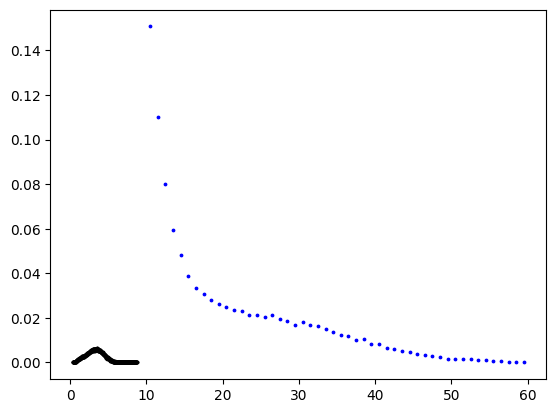

In [58]:
plt.scatter(bin_centers_trms, (pdf_sig_trms-pdf_bkg_trms*0.2)/0.8, s=3);
plt.scatter(bin_centers_nhits, (pdf_sig_nhits-pdf_bkg_nhits*0.2)/0.8, s=3);

In [26]:
len(trms_20_sig), len(nhits_sig)

(373879, 373879)

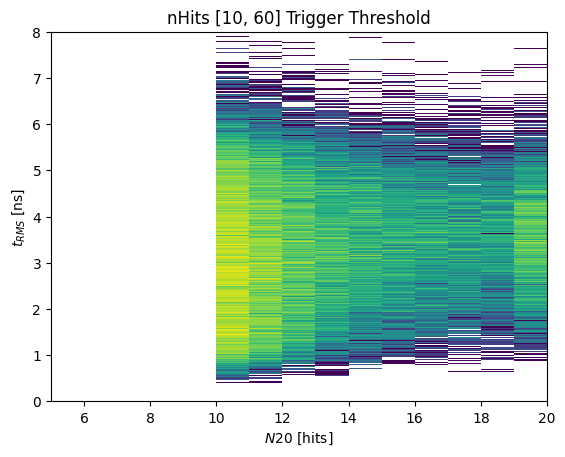

In [ ]:
mask = np.array(nhits_sig)<20
plt.hist2d(np.array(nhits_sig), np.array(trms_20_sig), (15,1000), norm="log", range=((10,20), (0,8)));
plt.xlabel("$N20$ [hits]");
plt.ylabel("$t_{RMS}$ [ns]");
plt.title("nHits [10, 60] Trigger Threshold");

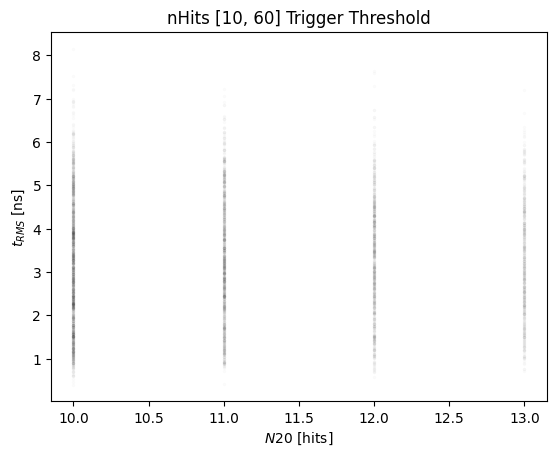

In [54]:
mask = np.array(nhits_sig)[:10000]<14
plt.scatter(np.array(nhits_sig)[:10000][mask], np.array(trms_20_sig)[:10000][mask], s=3, alpha=0.01);
plt.xlabel("$N20$ [hits]");
plt.ylabel("$t_{RMS}$ [ns]");
plt.title("nHits [10, 60] Trigger Threshold");

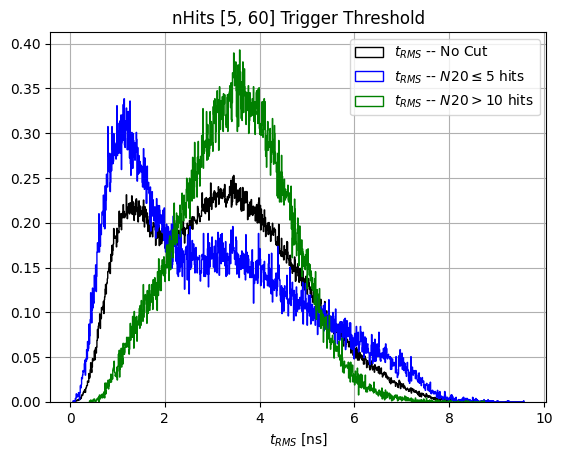

In [102]:
mask = np.array(nhits_sig)<15

pltext.hist(np.array(trms_20_sig),                         1000, xylabels=r"$t_{RMS}$ [ns]", stats=False, density=True, label=r"$t_{RMS}$ -- No Cut");
pltext.hist(np.array(trms_20_sig)[np.array(nhits_sig)<=5], 1000, xylabels=r"$t_{RMS}$ [ns]", stats=False, density=True, label=r"$t_{RMS}$ -- $N20 \leq 5$ hits");
pltext.hist(np.array(trms_20_sig)[np.array(nhits_sig)>10], 1000, xylabels=r"$t_{RMS}$ [ns]", stats=False, density=True, label=r"$t_{RMS}$ -- $N20 > 10$ hits");
plt.title("nHits [5, 60] Trigger Threshold");

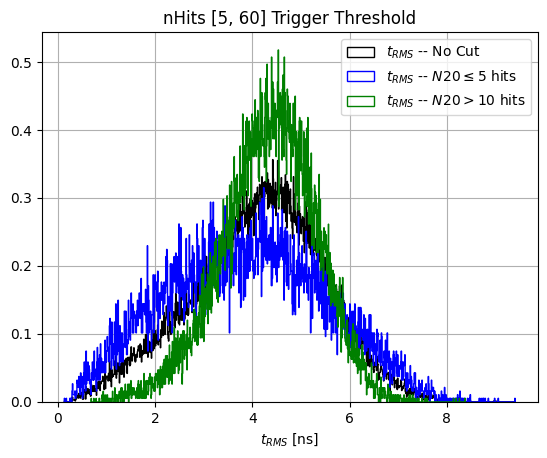

In [103]:
mask = np.array(nhits_bkg)<15

pltext.hist(np.array(trms_20_bkg),                         1000, xylabels=r"$t_{RMS}$ [ns]", stats=False, density=True, label=r"$t_{RMS}$ -- No Cut");
pltext.hist(np.array(trms_20_bkg)[np.array(nhits_bkg)<=5], 1000, xylabels=r"$t_{RMS}$ [ns]", stats=False, density=True, label=r"$t_{RMS}$ -- $N20 \leq 5$ hits");
pltext.hist(np.array(trms_20_bkg)[np.array(nhits_bkg)>10], 1000, xylabels=r"$t_{RMS}$ [ns]", stats=False, density=True, label=r"$t_{RMS}$ -- $N20 > 10$ hits");
plt.title("nHits [5, 60] Trigger Threshold");